## Figure 1 Literature Survey on SMILES Representations in Chemical Language Models

* 1-a Screening process

* 1-b Pie chart

([<matplotlib.patches.Wedge at 0x7520be7a6e90>,
 [Text(0.9432792849376579, 0.56588354862772, 'Canonicalized (RDKit)'),
  Text(0.8858387590917716, -0.6521423869759966, 'Canonicalized (Openbabel)'),
  Text(0.621146960925331, -0.9078416452957122, 'Canonicalized (Other)'),
  Text(0.23658399318162693, -1.0742569590978854, 'Not Canonicalized'),
  Text(-1.129910778591594, -0.014199733185448234, 'No Discription')],
 [Text(0.6431449670029485, 0.3858296922461727, '32.8%'),
  Text(0.603980972108026, -0.4446425365745431, '4.6%'),
  Text(0.4235092915399983, -0.6189829399743492, '6.1%'),
  Text(0.16130726807838197, -0.7324479266576491, '6.1%'),
  Text(-0.7799384135411003, -0.009801585738627985, '50.4%')])

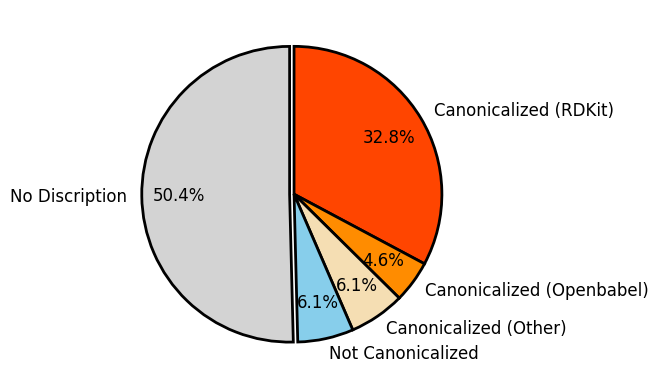

In [4]:
# Fig1-b
import numpy as np
import matplotlib.pyplot as plt 

x = np.array([32.8, 4.6, 6.1, 6.1, 50.4])
label = ["Canonicalized (RDKit)", "Canonicalized (Openbabel)", "Canonicalized (Other)", "Not Canonicalized", "No Discription"]
color = ["orangered","darkorange","wheat","skyblue","lightgray"]
plt.rcParams["font.size"] = 12
plt.pie(x, labels=label, counterclock=False, startangle=90, explode=[0, 0, 0, 0, 0.03], colors = color, wedgeprops={'linewidth': 2, 'edgecolor':"black"}, autopct="%1.1f%%",pctdistance=0.75)

## Figure 2 Extent of SMILES notational inconsistencies in public datasets.

* 2-a Distribution of syntactic variations in SMILES representations across datasets

* 2-b Example of SMILES syntactic variation

* 2-c Example of SMILES isomeric variation

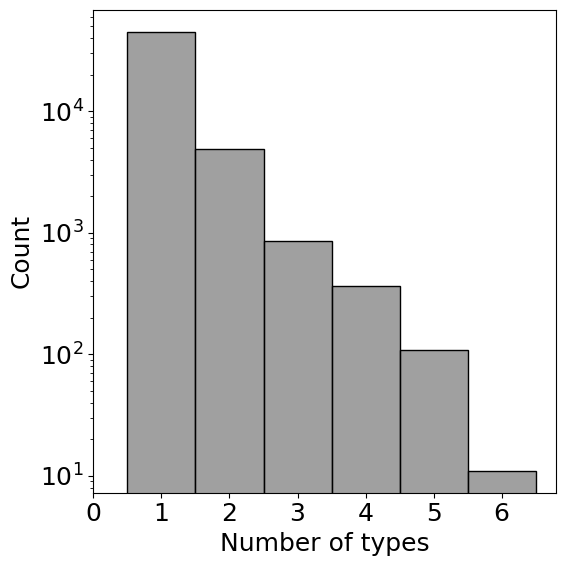

In [6]:
# Fig2-a
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
canonical = []
removed = []
dataset = []

Molecule = ["BBBP", "clintox", "HIV", "sider", "tox21", "toxcast_data"]

for mol in Molecule:
    df_can = pd.read_csv(f"/workspace/MoleculeNet/MoleculeNet_raw/{mol}.csv", header=None, names=["canonical"])
    df_rem = pd.read_csv(f"/workspace/MoleculeNet/MoleculeNet_3Dremoved/{mol}.csv", header=None, names=["removed"])
    
    canonical.extend(df_can["canonical"].tolist())
    removed.extend(df_rem["removed"].tolist())
    dataset.extend([mol] * len(df_can))

df_all = pd.DataFrame({
    "canonical": canonical,
    "removed": removed,
    "dataset": dataset
})

df_all.dropna(inplace=True)

grouped = df_all.groupby("removed")

unique_both_diff_counts = []

for removed_val, group in grouped:

    unique_pairs = set(zip(group["canonical"], group["dataset"]))
    selected_pairs = []
    unique_pairs = list(unique_pairs)

    used = set()

    
    for i in range(len(unique_pairs)):
        pair1 = unique_pairs[i]
        
        if pair1 not in used:
            selected_pairs.append(pair1)
            used.add(pair1)

            for j in range(i+1, len(unique_pairs)):
                pair2 = unique_pairs[j]
                if pair2[0] == pair1[0]:
                    used.add(pair2)

    
    G = nx.Graph()
    canonicals = set()
    datasets = set()

    for canonical, dataset in selected_pairs:
        G.add_node(canonical, bipartite=0)
        G.add_node(dataset, bipartite=1)
        G.add_edge(canonical, dataset)

        canonicals.add(canonical)
        datasets.add(dataset)


    matching = nx.bipartite.maximum_matching(G, top_nodes=canonicals)

    pairs = [(u, v) for u, v in matching.items() if u in canonicals]

    unique_both_diff_counts.append(len(pairs))

df_plot = pd.DataFrame({"Count": unique_both_diff_counts})
plt.rcParams["font.size"] = 18
plt.figure(figsize=(6, 6))
sns.histplot(df_plot, x="Count", bins=range(0, max(unique_both_diff_counts)), discrete=True, color='gray',log=True)
plt.xlabel("Number of types")
plt.xticks(range(7))
plt.tight_layout()
plt.show()

## Figure 3 Impact of SMILES Variations on Latent Representations

* 3-a  Bar plot of translation accuracy

* 3-b (SI 2,3) t-SNE visualization of latent representations 

* 3-c Scatter plot showing the correlation between normalized Levenshtein distance and the difference in latent representations

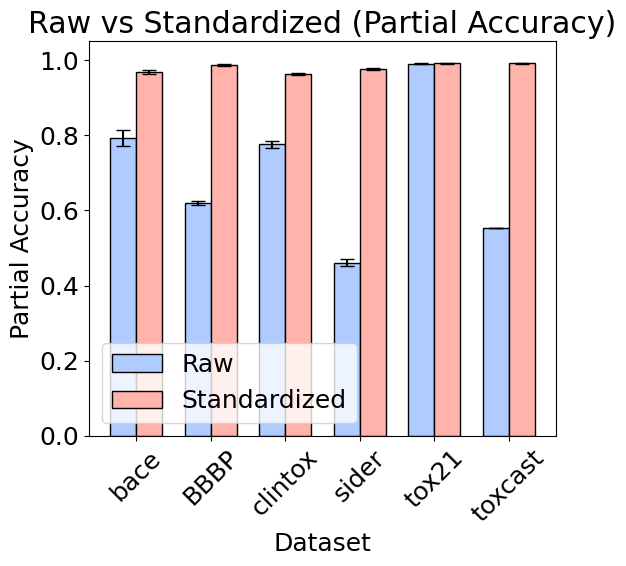

In [43]:
#Fig3-a
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfs = pd.read_csv("/workspace/2406_paper/summary_with_params.csv")

df_raw = dfs[(dfs["Param_3"] == "n") & (dfs["Param_5"] == "no")]
df_std = dfs[(dfs["Param_3"] == "n") & (dfs["Param_5"] == "n")]

Mol = ["bace", "BBBP", "clintox", "sider", "tox21", "toxcast"]

raw_means = []
std_means = []
raw_stds = []
std_stds = []

for mol in Mol:
    raw_scores = df_raw[df_raw["Param_6"] == mol]["Partial accuracy"]
    std_scores = df_std[df_std["Param_6"] == mol]["Partial accuracy"]

    raw_means.append(np.mean(raw_scores))
    std_means.append(np.mean(std_scores))
    raw_stds.append(np.std(raw_scores))
    std_stds.append(np.std(std_scores))


x = np.arange(len(Mol))  
width = 0.35 

fig, ax = plt.subplots(figsize=(6, 6))
plt.rcParams["font.size"] = 18
# Barplot with error bars
bars1 = ax.bar(x - width/2, raw_means, width, yerr=raw_stds, label='Raw', color='#AFCBFF', edgecolor='black', capsize=5)
bars2 = ax.bar(x + width/2, std_means, width, yerr=std_stds, label='Standardized', color='#FFB3AB', edgecolor='black', capsize=5)


ax.set_ylabel('Partial Accuracy')
ax.set_xlabel('Dataset')
ax.set_title('Raw vs Standardized (Partial Accuracy)')
ax.set_xticks(x)
ax.set_xticklabels(Mol,rotation=45)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


Using perplexity=30 for file: bace


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


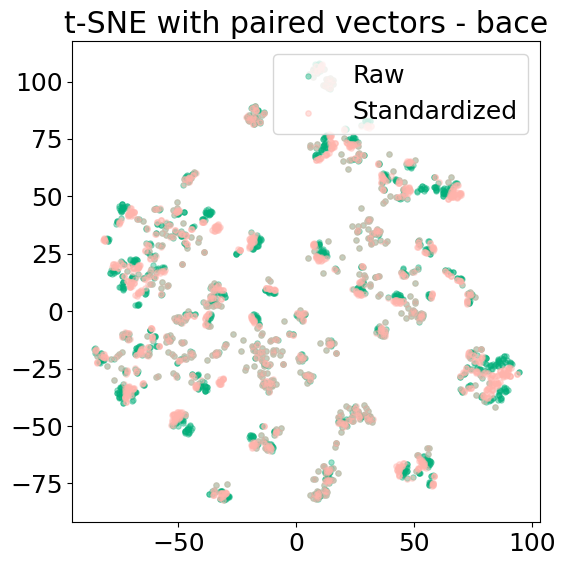

Using perplexity=40 for file: BBBP


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


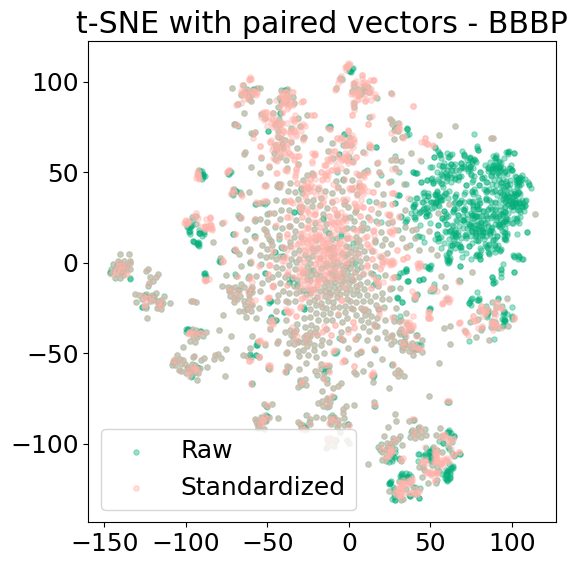

Using perplexity=29 for file: clintox


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


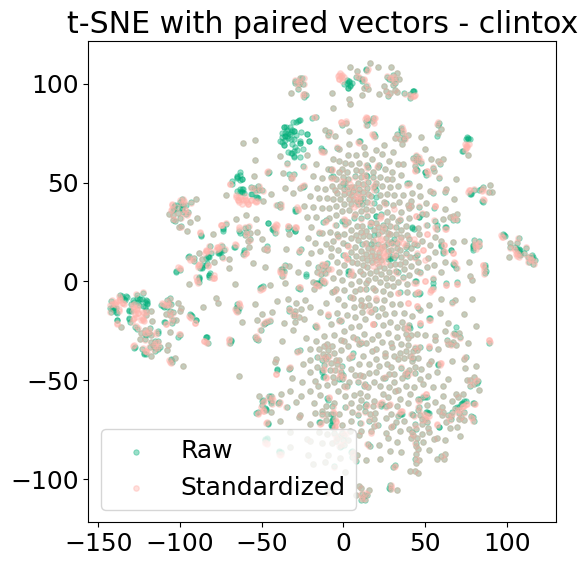

Using perplexity=27 for file: sider


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


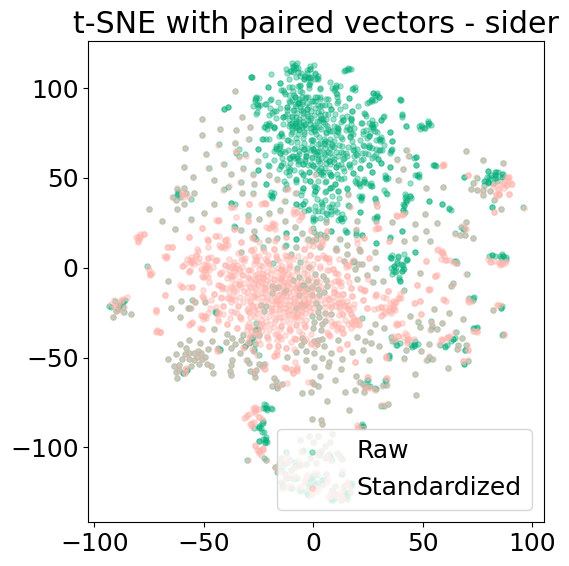

Using perplexity=50 for file: tox21


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


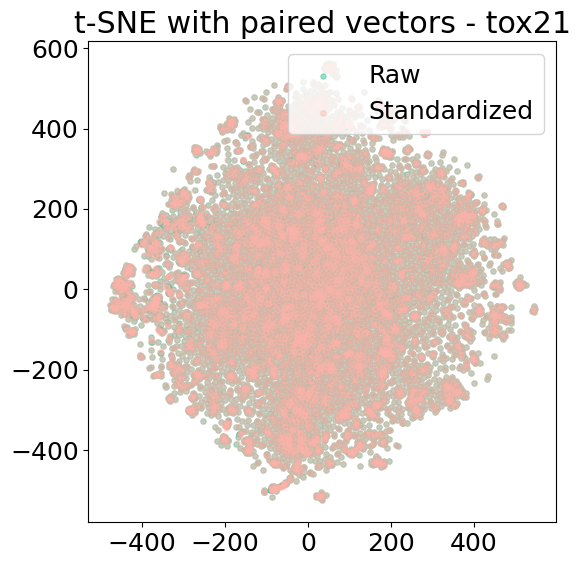

Using perplexity=50 for file: toxcast_data


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


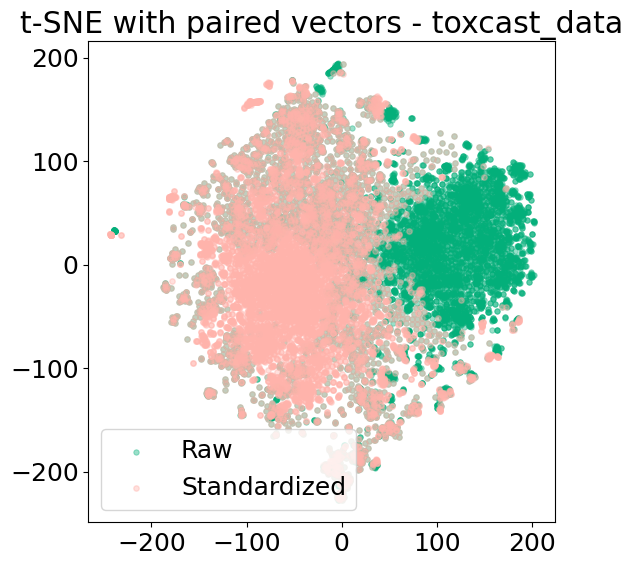

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import euclidean
# Figure 3-b
for fil in files:
    paired_data = []
    labels = []
    # Load latent representations
    file1 = f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_{fil}/accumulates/mu/0.npy"
    file2 = f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_{fil}/accumulates/mu/0.npy"

    data1 = np.load(file1)
    data2 = np.load(file2)

    min_len = min(len(data1), len(data2))
    data1 = data1[:min_len]
    data2 = data2[:min_len]

    for i in range(min_len):
        paired_data.append(data2[i])
        paired_data.append(data1[i])
        labels.append("Raw")
        labels.append("Standardized")

    paired_data_np = np.vstack(paired_data)
    data_size = len(paired_data_np)

    perplexity = int(np.clip(data_size * 0.01, 5, 50))
    print(f"Using perplexity={perplexity} for file: {fil}")

    reducer = TSNE(random_state=42, perplexity=30, n_iter=5000)
    embedding = reducer.fit_transform(paired_data_np)
    color_map = {
        "Raw": "#03AF7A",          # Green
        "Standardized": "#FFB3AB"  # Pink
    }

    plt.figure(figsize=(6, 6))
    plt.rcParams["font.size"] = 18
    for label in ["Raw", "Standardized"]:
        idx = [i for i, l in enumerate(labels) if l == label]
        
        if label == "Raw":
            plt.scatter(embedding[idx, 0], embedding[idx, 1],
                        facecolors=color_map[label],
                        edgecolors=color_map[label],
                        label=label,
                        alpha=0.4, s=15, linewidth=0.7)
        else:
            plt.scatter(embedding[idx, 0], embedding[idx, 1],
                        color=color_map[label],
                        label=label,
                        alpha=0.4, s=15)

    plt.title(f"t-SNE with paired vectors - {fil}")
    plt.legend()
    plt.tight_layout()
    plt.show()



Using perplexity=30 for file: bace


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


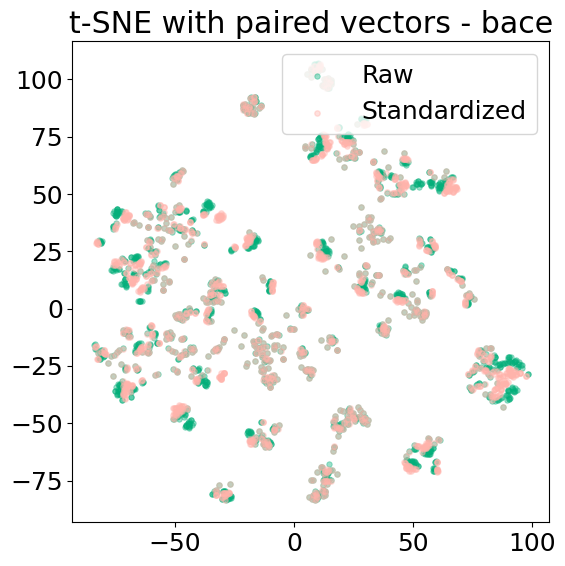

Using perplexity=40 for file: BBBP


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


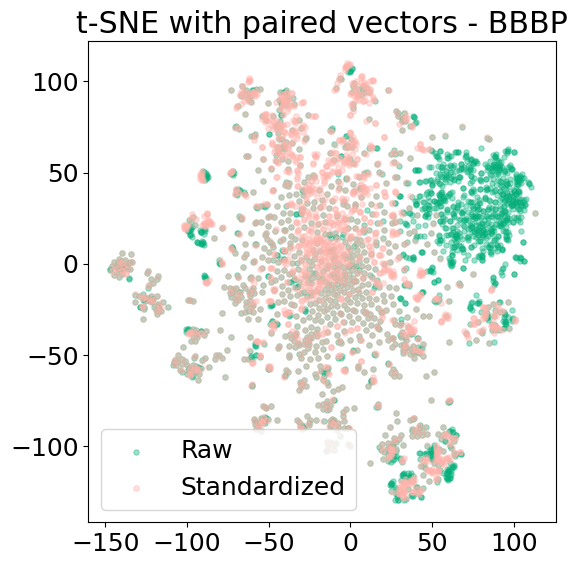

Using perplexity=29 for file: clintox


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


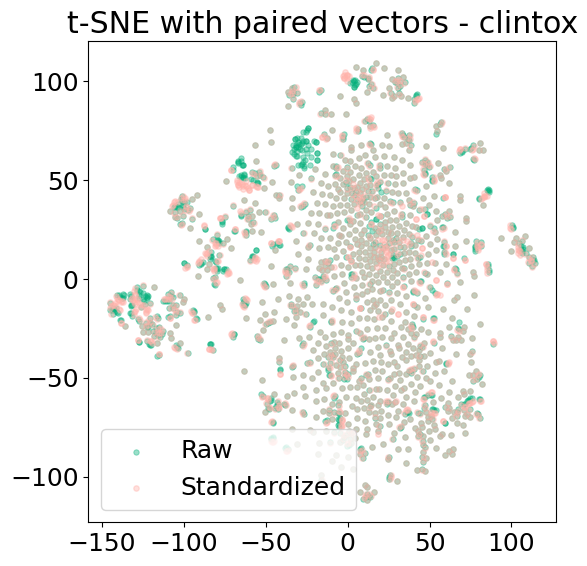

Using perplexity=27 for file: sider


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


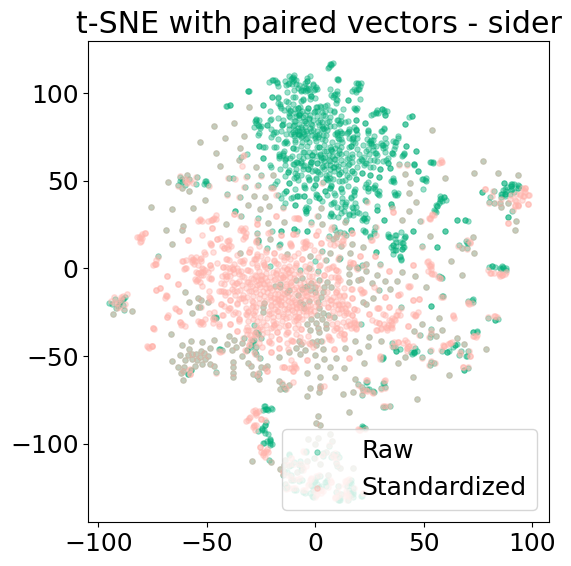

Using perplexity=50 for file: tox21


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


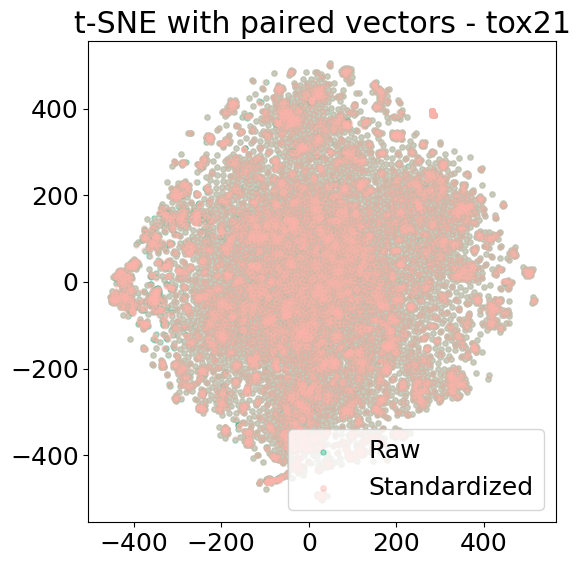

Using perplexity=50 for file: toxcast_data


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


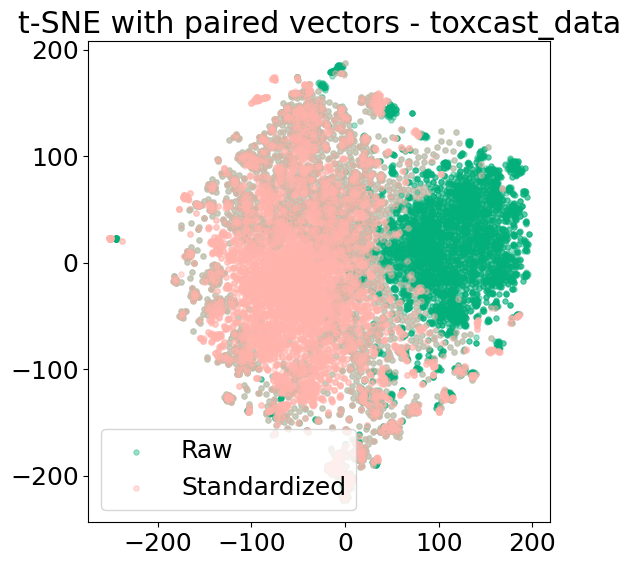

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import euclidean
files = ["bace","BBBP","clintox","sider","tox21","toxcast_data"]

# SI Figure2
for fil in files:
    paired_data = []
    labels = []
    # Load latent representations
    file1 = f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_{fil}/accumulates/mu/0.npy"
    file2 = f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_{fil}/accumulates/mu/0.npy"

    data1 = np.load(file1)
    data2 = np.load(file2)

    min_len = min(len(data1), len(data2))
    data1 = data1[:min_len]
    data2 = data2[:min_len]

    for i in range(min_len):
        paired_data.append(data2[i])
        paired_data.append(data1[i])
        labels.append("Raw")
        labels.append("Standardized")

    paired_data_np = np.vstack(paired_data)
    data_size = len(paired_data_np)

    perplexity = int(np.clip(data_size * 0.01, 5, 50))
    print(f"Using perplexity={perplexity} for file: {fil}")

    reducer = TSNE(random_state=72, perplexity=30, n_iter=5000)
    embedding = reducer.fit_transform(paired_data_np)
    color_map = {
        "Raw": "#03AF7A",          # Green
        "Standardized": "#FFB3AB"  # Pink
    }

    plt.figure(figsize=(6, 6))
    plt.rcParams["font.size"] = 18
    for label in ["Raw", "Standardized"]:
        idx = [i for i, l in enumerate(labels) if l == label]
        
        if label == "Raw":
            plt.scatter(embedding[idx, 0], embedding[idx, 1],
                        facecolors=color_map[label],
                        edgecolors=color_map[label],
                        label=label,
                        alpha=0.4, s=15, linewidth=0.7)
        else:
            plt.scatter(embedding[idx, 0], embedding[idx, 1],
                        color=color_map[label],
                        label=label,
                        alpha=0.4, s=15)

    plt.title(f"t-SNE with paired vectors - {fil}")
    plt.legend()
    plt.tight_layout()
    plt.show()


Using perplexity=30 for file: bace


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


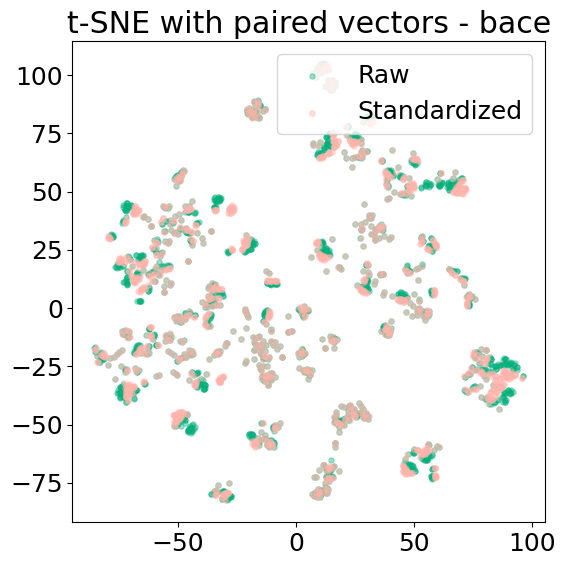

Using perplexity=40 for file: BBBP


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


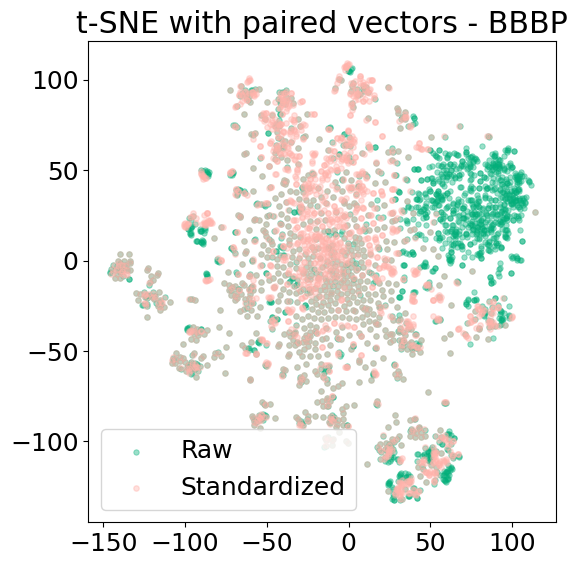

Using perplexity=29 for file: clintox


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


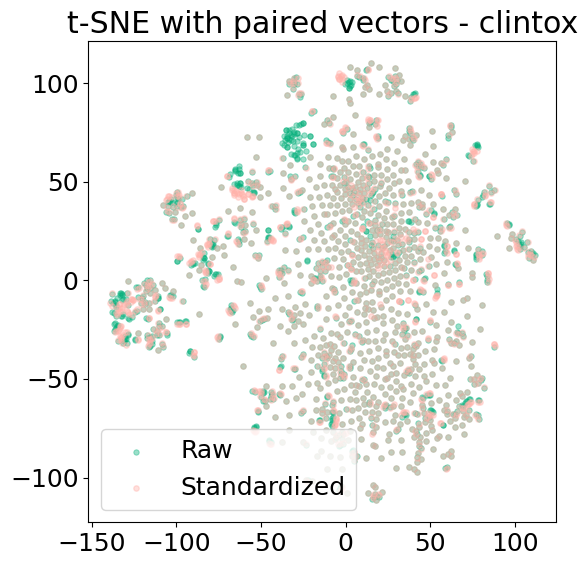

Using perplexity=27 for file: sider


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


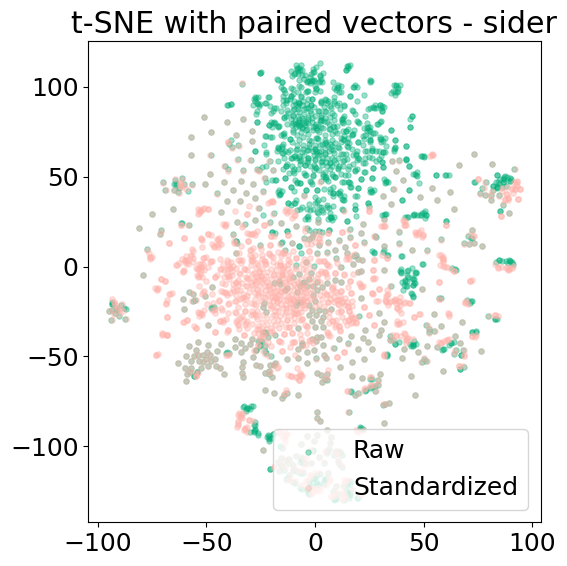

Using perplexity=50 for file: tox21


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


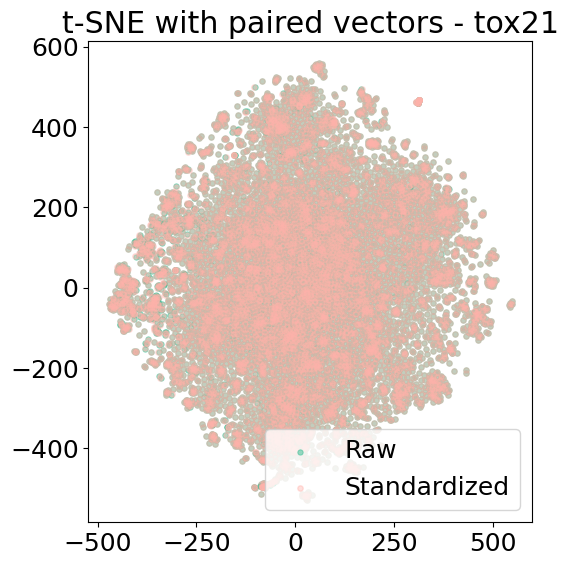

Using perplexity=50 for file: toxcast_data


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


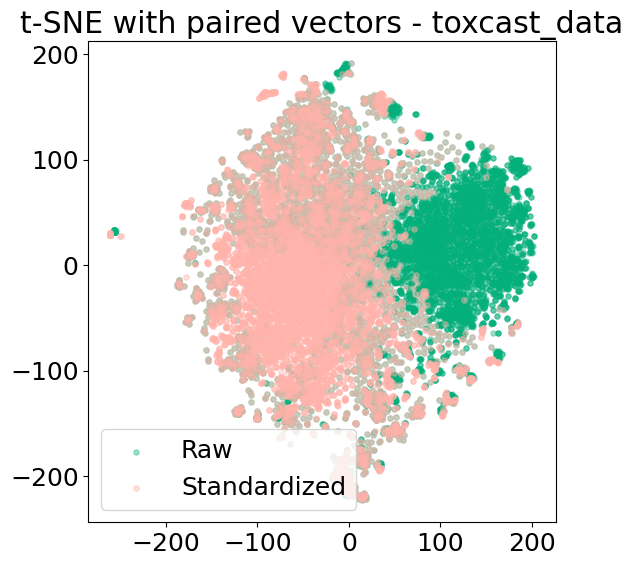

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.spatial.distance import euclidean
files = ["bace","BBBP","clintox","sider","tox21","toxcast_data"]

# SI Figure3
for fil in files:
    paired_data = []
    labels = []
    # Load latent representations
    file1 = f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_{fil}/accumulates/mu/0.npy"
    file2 = f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_{fil}/accumulates/mu/0.npy"

    data1 = np.load(file1)
    data2 = np.load(file2)

    min_len = min(len(data1), len(data2))
    data1 = data1[:min_len]
    data2 = data2[:min_len]

    for i in range(min_len):
        paired_data.append(data2[i])
        paired_data.append(data1[i])
        labels.append("Raw")
        labels.append("Standardized")

    paired_data_np = np.vstack(paired_data)
    data_size = len(paired_data_np)

    perplexity = int(np.clip(data_size * 0.01, 5, 50))
    print(f"Using perplexity={perplexity} for file: {fil}")

    reducer = TSNE(random_state=112, perplexity=30, n_iter=5000)
    embedding = reducer.fit_transform(paired_data_np)
    color_map = {
        "Raw": "#03AF7A",          # Green
        "Standardized": "#FFB3AB"  # Pink
    }

    plt.figure(figsize=(6, 6))
    plt.rcParams["font.size"] = 18
    for label in ["Raw", "Standardized"]:
        idx = [i for i, l in enumerate(labels) if l == label]
        
        if label == "Raw":
            plt.scatter(embedding[idx, 0], embedding[idx, 1],
                        facecolors=color_map[label],
                        edgecolors=color_map[label],
                        label=label,
                        alpha=0.4, s=15, linewidth=0.7)
        else:
            plt.scatter(embedding[idx, 0], embedding[idx, 1],
                        color=color_map[label],
                        label=label,
                        alpha=0.4, s=15)

    plt.title(f"t-SNE with paired vectors - {fil}")
    plt.legend()
    plt.tight_layout()
    plt.show()


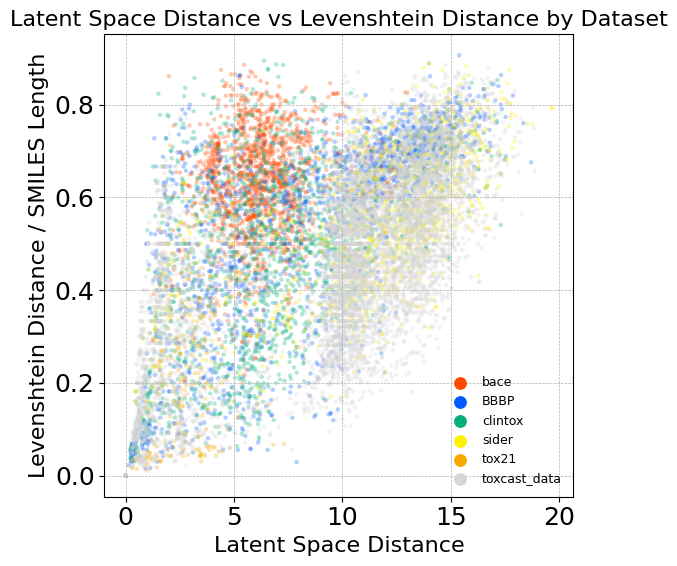

In [6]:
#3-C
import pickle
import Levenshtein
import matplotlib.pyplot as plt 
import numpy as np

files = ["bace","BBBP","clintox","sider","tox21","toxcast_data"]

custom_colors = [
    "#FF4B00",  # red
    "#005AFF",  # blue
    "#03AF7A",  # green
    "#FFF100",   # yellow
    "#F6AA00",  # cyan
    "#D6D6D6"  # orange
]

plt.rcParams["font.size"] = 18
plt.figure(figsize=(6, 6))

legend_handles = []

for idx, fil in enumerate(files):
    
    with open(f"/workspace/Transformers_VAE_ex/Molecule_canon/{fil}.pkl", "rb") as f:
        smiles_list = pickle.load(f)
    with open(f"/workspace/Transformers_VAE_ex/Molecule_non/{fil}.pkl", "rb") as f:
        smiles_list2 = pickle.load(f)
    matrix = np.load(f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_{fil}/accumulates/mu/0.npy")
    matrix2 = np.load(f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_{fil}/accumulates/mu/0.npy")

    lev_ratios = []
    vec_diffs = []

    for s1, s2, v1, v2 in zip(smiles_list, smiles_list2, matrix, matrix2):
        lev = Levenshtein.distance(s1, s2)
        max_len = max(len(s1), len(s2))
        lev_ratio = lev / max_len
        lev_ratios.append(lev_ratio)

        diff = np.linalg.norm(v1 - v2)  
        vec_diffs.append(diff)

    plt.scatter(vec_diffs, lev_ratios, alpha=0.3, s=10, color=custom_colors[idx], edgecolors='none')

    # plot for legend
    handle = plt.scatter([], [], color=custom_colors[idx], label=fil, s=30, alpha=1)
    legend_handles.append(handle)

plt.title("Latent Space Distance vs Levenshtein Distance by Dataset", fontsize=16)
plt.xlabel("Latent Space Distance", fontsize=16)
plt.ylabel("Levenshtein Distance / SMILES Length", fontsize=16)

plt.grid(True, linestyle='--', linewidth=0.5)

plt.legend(handles=legend_handles, markerscale=1.5, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


## Figure 4 Counterintuitive robustness in property prediction tasks

* 4-a Bar plot showing prediciton AUROC 

* 4-b,c,d,e Histograms of the differences in latent features

* 4-f Bar plot of the log p-values from Fisher’s exact test

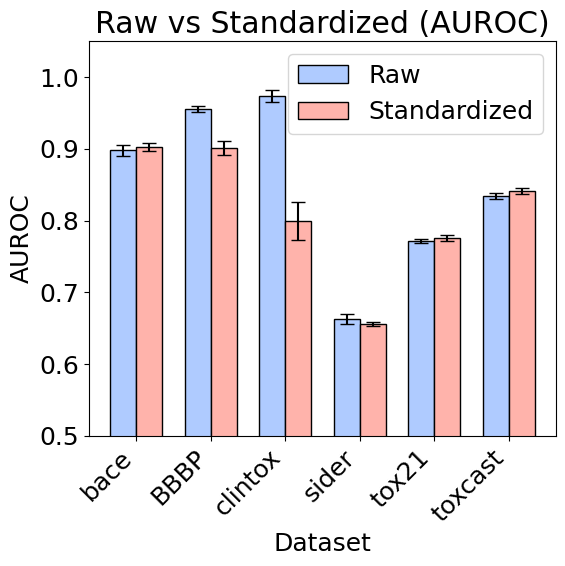

In [5]:
# 4-a
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/workspace/2406_paper/downstream.csv")  

data_long = []
for i in range(1, 4):
    for index, row in df.iterrows():
        data_long.append({
            'Dataset': row['data'],
            'Type': 'Raw',
            'Value': row[f'no{i}']
        })
        data_long.append({
            'Dataset': row['data'],
            'Type': 'Standardized',
            'Value': row[f'n{i}']
        })

df_long = pd.DataFrame(data_long)

summary = df_long.groupby(['Dataset', 'Type'])['Value'].agg(['mean', 'std']).reset_index()
ordered_datasets = ["bace", "BBBP", "clintox", "sider", "tox21", "toxcast"]

# Dataset列をカテゴリ型に変換して順番を固定
summary['Dataset'] = pd.Categorical(summary['Dataset'], categories=ordered_datasets, ordered=True)

# その順で並べ替える
summary = summary.sort_values('Dataset')
datasets = summary['Dataset'].unique()
x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(6,6))
plt.rcParams["font.size"] = 18
raw_means = summary[summary['Type'] == 'Raw']['mean'].values
std_means = summary[summary['Type'] == 'Standardized']['mean'].values
raw_stds = summary[summary['Type'] == 'Raw']['std'].values
std_stds = summary[summary['Type'] == 'Standardized']['std'].values

ax.bar(x - width/2, raw_means, width, yerr=raw_stds,
       label='Raw', color='#AFCBFF', edgecolor='black', capsize=5)
ax.bar(x + width/2, std_means, width, yerr=std_stds,
       label='Standardized', color='#FFB3AB', edgecolor='black', capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha='right')
ax.set_ylabel('AUROC')
ax.set_xlabel('Dataset')
ax.set_title('Raw vs Standardized (AUROC)')
ax.set_ylim(0.5, 1.05)
ax.legend()

plt.tight_layout()
plt.show()


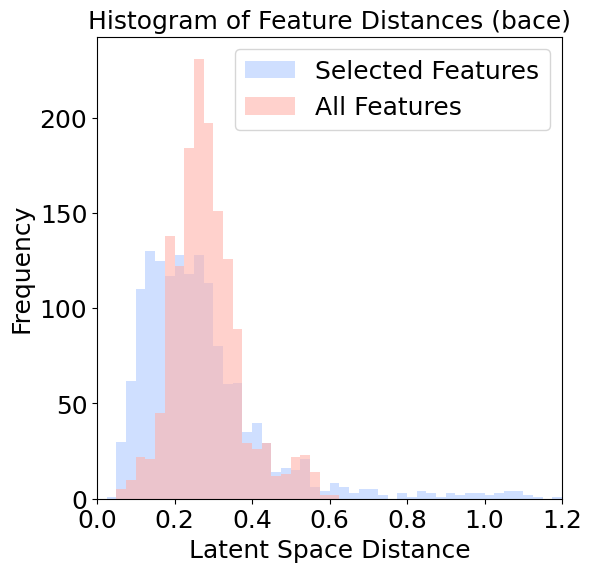

In [4]:
# 4-b(bace)
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as LA
import umap

file1 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_bace/accumulates/mu/0.npy"
file2 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_bace/accumulates/mu/0.npy"

data1 = np.load(file1)
data2 = np.load(file2)

cols = [494,474,492,9,368]
data1_sub = data1[:, cols]
data2_sub = data2[:, cols]

plt.rcParams["font.size"] = 18

distances1 = LA.norm(data1_sub - data2_sub, axis=1) / np.sqrt(data1_sub.shape[1])
distances2 = LA.norm(data1 - data2, axis=1) / np.sqrt(data1.shape[1])

bin_edges = np.linspace(0, 1.5, 61)  # 30 bins → 31 edges

plt.figure(figsize=(6,6))
plt.hist(distances1, bins=bin_edges, alpha=0.6, color="#AFCBFF", label="Selected Features")
plt.hist(distances2, bins=bin_edges, alpha=0.6, color="#FFB3AB", label="All Features")
plt.title("Histogram of Feature Distances (bace)", fontsize=18)
plt.xlabel("Latent Space Distance")
plt.ylabel("Frequency")
plt.xlim(0, 1.2)
plt.legend()
plt.show()

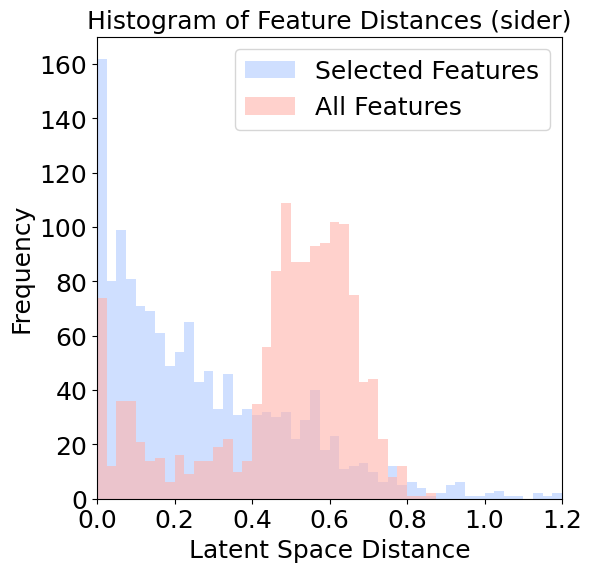

In [5]:
# 4-c(sider)
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as LA
import umap

file1 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_sider/accumulates/mu/0.npy"
file2 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_sider/accumulates/mu/0.npy"

data1 = np.load(file1)
data2 = np.load(file2)

cols = [309,145,124,21]
data1_sub = data1[:, cols]
data2_sub = data2[:, cols]

plt.rcParams["font.size"] = 18

distances1 = LA.norm(data1_sub - data2_sub, axis=1) / np.sqrt(data1_sub.shape[1])
distances2 = LA.norm(data1 - data2, axis=1) / np.sqrt(data1.shape[1])
bin_edges = np.linspace(0, 1.5, 61)  # 30 bins → 31 edges

plt.figure(figsize=(6,6))
plt.hist(distances1, bins=bin_edges, alpha=0.6, color="#AFCBFF", label="Selected Features")
plt.hist(distances2, bins=bin_edges, alpha=0.6, color="#FFB3AB", label="All Features")
plt.title("Histogram of Feature Distances (sider)", fontsize=18)
plt.xlabel("Latent Space Distance")
plt.ylabel("Frequency")
plt.xlim(0, 1.2)
plt.legend()
plt.show()


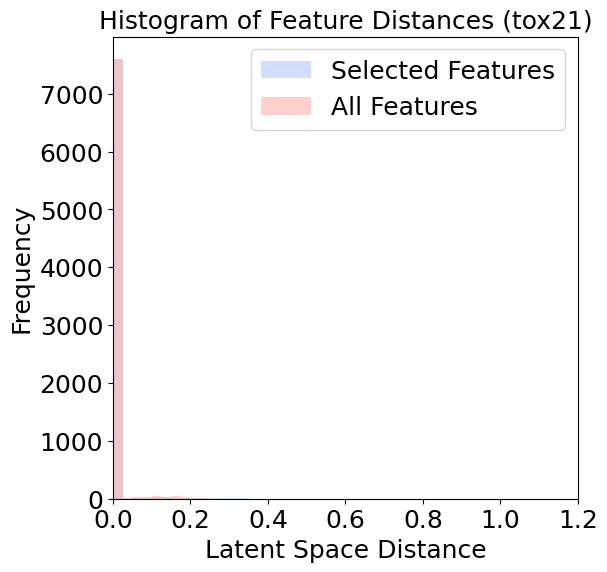

In [6]:
# 4-d(tox21)
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as LA
import umap

file1 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_tox21/accumulates/mu/0.npy"
file2 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_tox21/accumulates/mu/0.npy"

data1 = np.load(file1)
data2 = np.load(file2)

cols = [494,150,492,116,256,110,8,49,360,270,316,38,137,471,373,95]
data1_sub = data1[:, cols]
data2_sub = data2[:, cols]

plt.rcParams["font.size"] = 18

distances1 = LA.norm(data1_sub - data2_sub, axis=1) / np.sqrt(data1_sub.shape[1])
distances2 = LA.norm(data1 - data2, axis=1) / np.sqrt(data1.shape[1])
bin_edges = np.linspace(0, 1.5, 61)  # 30 bins → 31 edges

plt.figure(figsize=(6,6))
plt.hist(distances1, bins=bin_edges, alpha=0.6, color="#AFCBFF", label="Selected Features")
plt.hist(distances2, bins=bin_edges, alpha=0.6, color="#FFB3AB", label="All Features")
plt.title("Histogram of Feature Distances (tox21)", fontsize=18)
plt.xlabel("Latent Space Distance")
plt.ylabel("Frequency")
plt.xlim(0, 1.2)
plt.ylim(0,)
plt.legend()
plt.show()

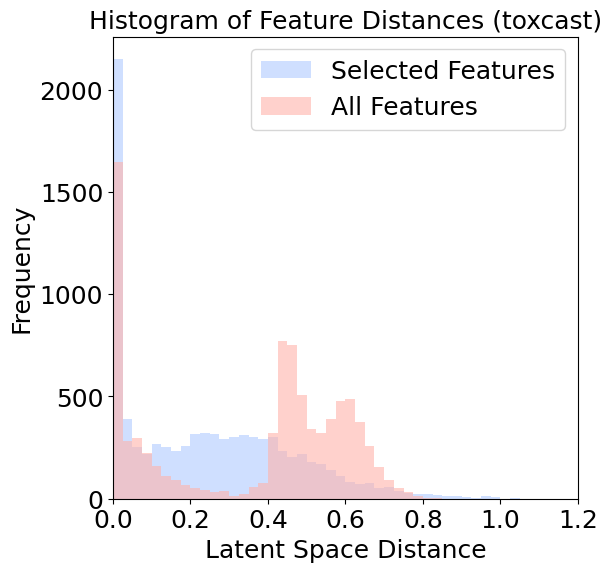

In [7]:
# 4-e(toxcast)
import numpy as np
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy.linalg as LA

file1 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_toxcast_data/accumulates/mu/0.npy"
file2 = "/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_toxcast_data/accumulates/mu/0.npy"

data1 = np.load(file1)
data2 = np.load(file2)

cols = [494,418,1,78,21,345]
data1_sub = data1[:, cols]
data2_sub = data2[:, cols]

plt.rcParams["font.size"] = 18

distances1 = LA.norm(data1_sub - data2_sub, axis=1) / np.sqrt(data1_sub.shape[1])
distances2 = LA.norm(data1 - data2, axis=1) / np.sqrt(data1.shape[1])
bin_edges = np.linspace(0, 1.5, 61)  # 30 bins → 31 edges

plt.figure(figsize=(6,6))
plt.hist(distances1, bins=bin_edges, alpha=0.6, color="#AFCBFF", label="Selected Features")
plt.hist(distances2, bins=bin_edges, alpha=0.6, color="#FFB3AB", label="All Features")
plt.title("Histogram of Feature Distances (toxcast)", fontsize=18)
plt.xlabel("Latent Space Distance")
plt.ylabel("Frequency")
plt.xlim(0, 1.2)
plt.legend()
plt.show()

bace | Top-10 | Fisher's p-value: 1.4718e-05
bace | Top-20 | Fisher's p-value: 4.4071e-05
bace | Top-30 | Fisher's p-value: 1.4583e-05
bace | Top-40 | Fisher's p-value: 1.9901e-03
bace | Top-50 | Fisher's p-value: 5.0913e-03
sider | Top-10 | Fisher's p-value: 1.4231e-02
sider | Top-20 | Fisher's p-value: 5.5056e-03
sider | Top-30 | Fisher's p-value: 5.3120e-03
sider | Top-40 | Fisher's p-value: 2.7800e-02
sider | Top-50 | Fisher's p-value: 2.0117e-02
tox21 | Top-10 | Fisher's p-value: 1.7664e-09
tox21 | Top-20 | Fisher's p-value: 3.6451e-09
tox21 | Top-30 | Fisher's p-value: 6.7836e-09
tox21 | Top-40 | Fisher's p-value: 7.2420e-12
tox21 | Top-50 | Fisher's p-value: 6.9242e-12
toxcast_data | Top-10 | Fisher's p-value: 1.8046e-01
toxcast_data | Top-20 | Fisher's p-value: 4.4071e-05
toxcast_data | Top-30 | Fisher's p-value: 9.1595e-04
toxcast_data | Top-40 | Fisher's p-value: 1.1499e-05
toxcast_data | Top-50 | Fisher's p-value: 1.4531e-03


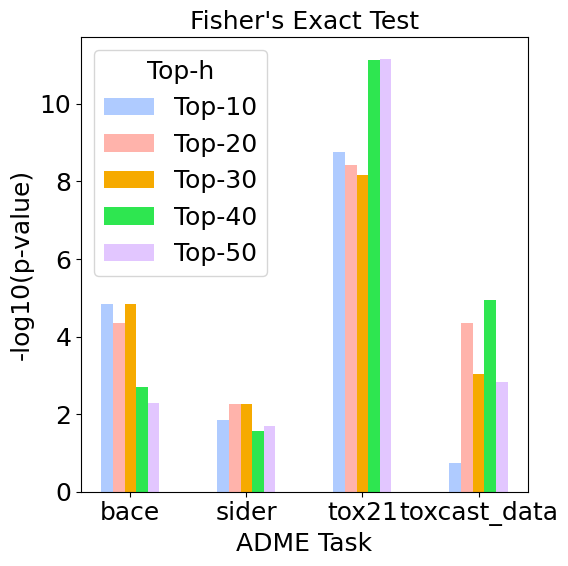

In [9]:
#Fig 4-f
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import math

ADME = ["bace", "sider", "tox21", "toxcast_data"]
H_VALUES = [10, 20, 30, 40, 50]

pval_dict = {h: {} for h in H_VALUES}

for adme in ADME:
    for h in H_VALUES:
        A = np.load(f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_no_{adme}/feature_importances.npy") 
        B = np.load(f"/workspace/Transformers_VAE_ex/result_ADME/250509_AllPubchem_Mol_n_1_n_{adme}/feature_importances.npy")

        top_A = set(np.argsort(A)[::-1][:h])
        top_B = set(np.argsort(B)[::-1][:h])
        all_features = set(range(512))

        TP = len(top_A & top_B)
        FP = len(top_A - top_B)
        FN = len(top_B - top_A)
        TN = len(all_features - (top_A | top_B))

        confusion_matrix = np.array([[TP, FP],
                                     [FN, TN]])

        _, p_value = fisher_exact(confusion_matrix)
        pval_dict[h][adme] = p_value
        print(f"{adme} | Top-{h} | Fisher's p-value: {p_value:.4e}")

colors = ["#AFCBFF","#FFB3AB","#F6AA00","#2EE650","#E2C6FF"]
bar_width = 0.1
num_h = len(H_VALUES)
x = np.arange(len(ADME))  

plt.figure(figsize=(6, 6))

for i, h in enumerate(H_VALUES):
    log_pvals = []
    for adme in ADME:
        p = pval_dict[h][adme]
        log_pvals.append(-math.log10(max(p, 1e-300)))

    bar_pos = x + (i - num_h / 2) * bar_width + bar_width / 2
    plt.bar(bar_pos, log_pvals, width=bar_width, color=colors[i % len(colors)], label=f"Top-{h}")

plt.xticks(x, ADME, fontsize=18)
plt.ylabel("-log10(p-value)", fontsize=18)
plt.xlabel("ADME Task", fontsize=18)
plt.title("Fisher's Exact Test", fontsize=18)
plt.legend(title="Top-h")
plt.tight_layout()
plt.show()

## Figure 5 Confounding artifacts from Kekulé/aromatic mismatch in ClinTox

* 5-a Example SMILES illustrating the K/A mismatch in aromatic ring notation

* 5-b Distribution of positive and negative labels in the ClinTox dataset

* 5-c ROC curve for the model trained on Raw SMILES in the ClinTox dataset

* 5-d Running sum plot demonstrating the enrichment of K/A mismatch compounds at the early region of the ROC curve

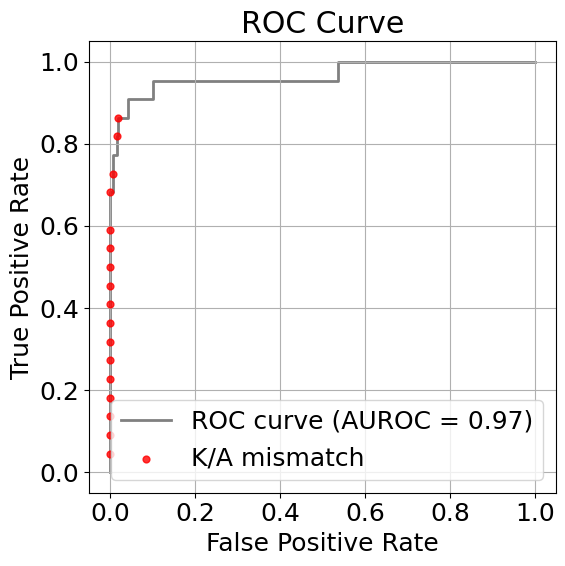

In [13]:
#Fig 5-c
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
from rdkit import Chem
import matplotlib.patches as mpatches

df = pd.read_csv("/workspace/2406_paper/clintox_predict.csv")

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

df["canonical_smiles"] = df["smiles"].apply(canonicalize)

df["is_variation"] = (
    ~df["smiles"].str.contains("c", case=True, na=False) &
     df["canonical_smiles"].str.contains("c", case=True, na=False)
)

y_true = df["Y"]
y_score = df["predict"]
is_variation = df["is_variation"]

y_true = np.array(y_true)
y_score = np.array(y_score)
is_variation = np.array(is_variation)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

sorted_indices = np.argsort(-y_score)
y_true_sorted = y_true[sorted_indices]
y_score_sorted = y_score[sorted_indices]
is_variation_sorted = is_variation[sorted_indices]

fpr_points = []
tpr_points = []
colors = []

tp = 0
fp = 0
P = sum(y_true)
N = len(y_true) - P

fpr_points = []
tpr_points = []
highlight_fpr = []
highlight_tpr = []

for i in range(len(y_true_sorted)):
    if y_true_sorted[i] == 1:
        tp += 1
    else:
        fp += 1
    fpr_i = fp / N
    tpr_i = tp / P
    fpr_points.append(fpr_i)
    tpr_points.append(tpr_i)

    if is_variation_sorted[i]:
        highlight_fpr.append(fpr_i)
        highlight_tpr.append(tpr_i)

plt.rcParams["font.size"] = 18

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='gray', lw=2, label=f'ROC curve (AUROC = {roc_auc:.2f})',zorder=1)
plt.scatter(highlight_fpr, highlight_tpr, c='red', s=24,alpha=0.8, label='K/A mismatch',zorder=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


{'D': 0.9927797833935018, 'D_signed': 0.9927797833935018, 'argmax': 18, 'n_pos': 17, 'n_neg': 277}


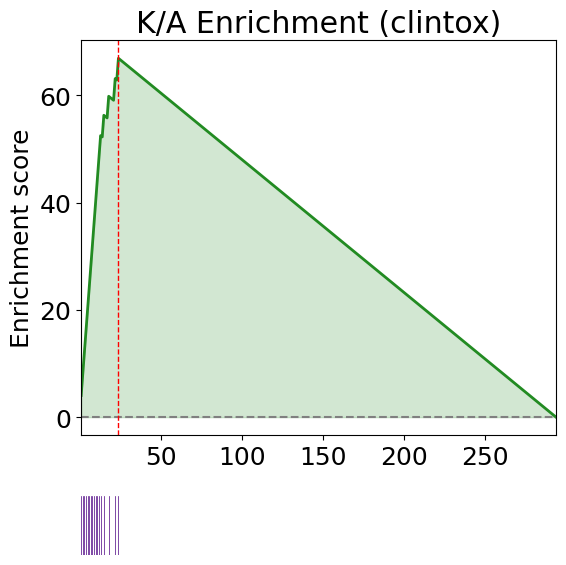

{'D': 66.8880200052043,
 'D_signed': 66.8880200052043,
 'argmax': 23,
 'n_pos': 17,
 'n_neg': 277}

In [22]:
#Fig 5-d
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score, roc_curve, auc
import pandas as pd
from rdkit import Chem

def _validate_inputs(weights: np.ndarray, ka_binary: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Validate and align input vectors."""
    w = np.asarray(weights, dtype=float).ravel()
    b = np.asarray(ka_binary, dtype=int).ravel()
    if w.shape[0] != b.shape[0]:
        raise ValueError(f"Length mismatch: weights={w.shape[0]}, ka_binary={b.shape[0]}")
    if np.any(~np.isfinite(w)):
        raise ValueError("weights contain non-finite values")
    if np.any((b != 0) & (b != 1)):
        raise ValueError("ka_binary must be a binary vector of 0/1")
    return w, b

def ks_statistic_sorted(weights: np.ndarray, ka_binary: np.ndarray) -> Dict[str, float]:
    """
    Compute KS statistic after sorting by weights (descending).

    Parameters
    ----------
    weights : array-like of shape (n_samples,)
        Per-sample weights (e.g., AUROC contributions). Larger means more important.
    ka_binary : array-like of shape (n_samples,)
        Binary indicator for K/A mismatch (1 = mismatch, 0 = no mismatch).

    Returns
    -------
    dict with keys:
        D : KS statistic (max absolute difference)
        D_signed : Signed KS (positive if K/A enriched at top)
        argmax : index (in sorted order) where |diff| is maximized
        n_pos : number of K/A=1 samples
        n_neg : number of K/A=0 samples
    """
    w, b = _validate_inputs(weights, ka_binary)

    # Sort by weights descending
    order = np.argsort(-w)
    b_sorted = b[order]

    # Empirical CDFs as we move down the ranked list
    n = b_sorted.size
    n_pos = b_sorted.sum()
    n_neg = n - n_pos
    if n_pos == 0 or n_neg == 0:
        raise ValueError("Both classes must be present (need some 0s and some 1s).")

    # Cumulative counts for positives and negatives
    cum_pos = np.cumsum(b_sorted) / n_pos
    cum_neg = np.cumsum(1 - b_sorted) / n_neg

    diff = cum_pos - cum_neg
    argmax = int(np.argmax(np.abs(diff)))
    D = float(np.abs(diff[argmax]))
    D_signed = float(diff[argmax])

    return {
        "D": D,
        "D_signed": D_signed,
        "argmax": argmax,
        "n_pos": int(n_pos),
        "n_neg": int(n_neg),
    }

def plot_running_sum(contribs_sorted, is_variation_sorted, perm,
                     title="K/A Enrichment (clintox)", 
                     color="forestgreen", alpha=0.2, 
                     barcode_color="indigo", barcode_size=0.15,
                     xlabel="Rank in ordered samples", 
                     ylabel="Enrichment score", 
                     figsize=(6,6), dpi=100, fileout=None):
    """
    Plot running sum enrichment plot (GSEA-style) with barcode tracks.

    Parameters
    ----------
    contribs_sorted : 1d array-like
        Sorted contributions (descending).
    is_variation_sorted : 1d array-like (binary)
        Sorted binary vector (1 = variation, 0 = otherwise).
    title : str
        Plot title.
    color : str
        Color of enrichment curve.
    alpha : float
        Transparency for filled area under curve.
    barcode_color : str
        Color for barcode ticks.
    barcode_size : float
        Relative size of barcode track.
    xlabel, ylabel : str
        Axis labels.
    figsize : tuple
        Figure size.
    dpi : int
        Figure resolution.
    fileout : str or None
        If provided, save to file.
    """

    contribs_sorted = np.array(contribs_sorted)
    is_variation_sorted = np.array(is_variation_sorted).astype(bool)
    n = len(contribs_sorted)

    # enrichment curve (running sum, KS-style)
    n_pos = is_variation_sorted.sum()
    n_neg = n - n_pos
    inc = np.sqrt(n_neg/n_pos) if n_pos > 0 else 0
    dec = -np.sqrt(n_pos/n_neg) if n_neg > 0 else 0
    running = np.cumsum(np.where(is_variation_sorted, inc, dec))
    x = np.arange(1, n+1)

    # max deviation
    argmax = np.argmax(np.abs(running))
    D_signed = running[argmax]

    # layout
    fig = plt.figure(figsize=figsize, dpi=dpi)
    spec = gridspec.GridSpec(ncols=1, nrows=2, height_ratios=[1, barcode_size])

    # main axis
    ax = fig.add_subplot(spec[0,0])
    ax.plot(x, running, color=color, lw=2)
    ax.fill_between(x, 0, running, color=color, alpha=alpha)
    ax.axhline(0, color="gray", ls="--")
    ax.axvline(x[argmax], color="red", ls="--", lw=1)
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, n)
    ax.set_title(title)

    # barcode axis
    axb = fig.add_subplot(spec[1,0], sharex=ax)
    ylim = [-1, 1]
    for i, l in enumerate(is_variation_sorted):
        if l:
            axb.plot([x[i], x[i]], ylim, color=barcode_color, lw=0.5)
    axb.set_ylim(ylim)
    axb.set_xlabel(xlabel)
    axb.axis("off")
    plt.tight_layout()

    if fileout:
        plt.savefig(fileout, bbox_inches="tight", dpi=dpi)
    plt.show()

    return {"D": abs(D_signed), "D_signed": D_signed, "argmax": argmax, "n_pos": n_pos, "n_neg": n_neg}


def loo_auroc_contributions(y_true, y_score):
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    
    full_auroc = roc_auc_score(y_true, y_score)
    
    contributions = np.zeros(len(y_true))
    
    for i in range(len(y_true)):
        mask = np.ones(len(y_true), dtype=bool)
        mask[i] = False
        
        try:
            loo_auroc = roc_auc_score(y_true[mask], y_score[mask])
            contributions[i] = full_auroc - loo_auroc
        except ValueError:
            contributions[i] = np.nan
    
    return contributions


df = pd.read_csv("/workspace/2406_paper/clintox_predict.csv")

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

df["canonical_smiles"] = df["smiles"].apply(canonicalize)

df["is_variation"] = (
    ~df["smiles"].str.contains("c", case=True, na=False) &
     df["canonical_smiles"].str.contains("c", case=True, na=False)
)

y_true = df["Y"]
y_score = df["predict"]
is_variation = df["is_variation"]

contribs = loo_auroc_contributions(y_true, y_score)
df["contribs"] = contribs
plt.rcParams["font.size"] = 18

order = np.argsort(-y_score)

contribs_sorted = contribs[order]
is_variation_sorted = is_variation[order]

res = ks_statistic_sorted(contribs_sorted, is_variation_sorted)
print(res)  # {"D": ..., "D_signed": ..., "argmax": ..., "n_pos": ..., "n_neg": ...}

plot_running_sum(contribs_sorted, is_variation_sorted,perm)

## Figure S1 Score Differences Between Models Trained on Latent Representations Derived from Raw and Standardized SMILES

* S1-a Plots of partial accuracy scores(MoleculeNet)

* S1-b Mean Levenshtein Distance

* S1-c Bar Plots of partial accuracy scores(TDC)

/tmp/ipykernel_2311878/1518421743.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(df['Study'], fontsize=18)


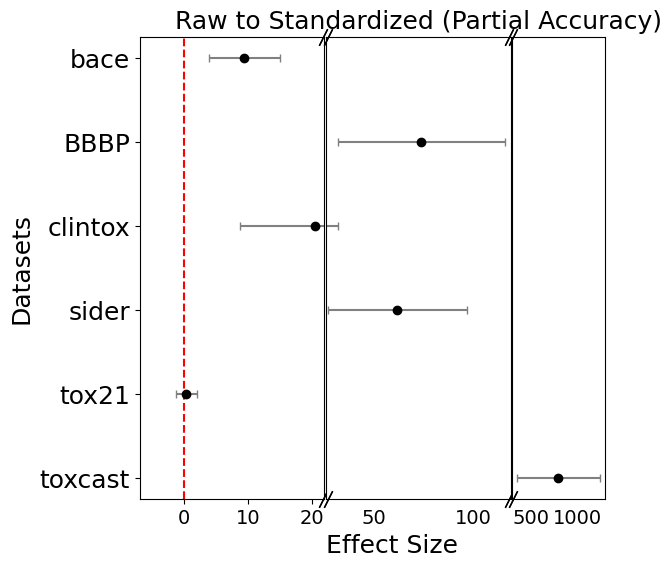

In [24]:
#Fig S1-a

import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

eff =[]
ci_l = []
ci_u = []
dif = []
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfs = pd.read_csv("/workspace/2406_paper/summary_with_params.csv")

df1 = dfs[(dfs["Param_3"] == "n") & (dfs["Param_5"] == "no")]
df2 = dfs[(dfs["Param_3"] == "n") & (dfs["Param_5"] == "n")]

Mol = ["bace", "BBBP", "clintox", "sider", "tox21", "toxcast"]

for tox in Mol: 
    if tox == "":
        eff.append(-2000)
        dif.append(0)
        ci_l.append(-2000)
        ci_u.append(-2000)
        continue
    control_group = np.array(df1[df1["Param_6"]== tox]["Partial accuracy"])
    comparison_group =  np.array(df2[df2["Param_6"]==tox]["Partial accuracy"])
    mean_comparison = np.mean(comparison_group)
    mean_control = np.mean(control_group)
    

    std_comparison = np.std(comparison_group, ddof=1)
    std_control = np.std(control_group, ddof=1)
    

    n_comparison = len(comparison_group)
    n_control = len(control_group)


    pooled_std = np.sqrt(((n_comparison - 1) * std_comparison**2 + (n_control - 1) * std_control**2) / (n_comparison + n_control - 2))


    effect_size = (mean_comparison - mean_control) / pooled_std


    se_d = np.sqrt((n_comparison + n_control) / (n_comparison * n_control) + effect_size**2 / (2 * (n_comparison + n_control)))

    ci_lower = effect_size - 1.96 * se_d
    ci_upper = effect_size + 1.96 * se_d
    eff.append(effect_size)
    dif.append(se_d ** 2)
    ci_l.append(ci_lower)
    ci_u.append(ci_upper)
    #print(f'Effect Size (Cohen\'s d): {effect_size:.4f}')
    #print(f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')

effect_sizes = np.array(eff)
variances = np.array(dif)  

eff.reverse()
ci_l.reverse()
ci_u.reverse()
Mol.reverse()

data = {
    'Study': Mol,
    'Effect Size': eff,
    'Lower CI': ci_l,
    'Upper CI': ci_u
}

df = pd.DataFrame(data)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(6, 6),width_ratios=[2,2,1])
fig.subplots_adjust(wspace=0.01)
plt.rcParams["font.size"] = 18
ax1.errorbar(df['Effect Size'], df['Study'], xerr=[df['Effect Size'] - df['Lower CI'], df['Upper CI'] - df['Effect Size']], fmt='o', color='black', ecolor='gray', capsize=3)
ax1.axvline(0, color='red', linestyle='--')
ax1.set_yticklabels(df['Study'], fontsize=18)

ax2.set_xlabel('Effect Size', fontsize=18, loc='left')
ax1.set_ylabel('Datasets',  fontsize=18)
ax1.set_xlim(-7,22)
ax2.set_title('Raw to Standardized (Partial Accuracy)', fontsize=18, loc='center')


ax2.errorbar(df['Effect Size'], df['Study'], xerr=[df['Effect Size'] - df['Lower CI'], df['Upper CI'] - df['Effect Size']], fmt='o', color='black', ecolor='gray', capsize=3)


ax2.set_xlim(26,119)
ax2.tick_params(bottom=False, left=False, right=False, top=False)
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0.99,0.99], [0,0], transform=ax1.transAxes, **kwargs)
ax1.plot([0.99,0.99], [1,1], transform=ax1.transAxes, **kwargs)
ax2.plot([0.01,0.01], [1,1], transform=ax2.transAxes, **kwargs)
ax2.plot([0.01,0.01], [0,0], transform=ax2.transAxes, **kwargs)

ax2.plot([0.99,0.99], [0,0], transform=ax2.transAxes, **kwargs)
ax2.plot([0.99,0.99], [1,1], transform=ax2.transAxes, **kwargs)
ax3.plot([0.01,0.01], [1,1], transform=ax3.transAxes, **kwargs)
ax3.plot([0.01,0.01], [0,0], transform=ax3.transAxes, **kwargs)

ax3.errorbar(df['Effect Size'], df['Study'], xerr=[df['Effect Size'] - df['Lower CI'], df['Upper CI'] - df['Effect Size']], fmt='o', color='black', ecolor='gray', capsize=3)

ax3.set_xlim(300,1300)
ax3.tick_params(bottom=False, left=False, right=False, top=False)
ax1.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='x', labelsize=14)

plt.setp(ax3.get_yticklabels(), visible=False)
plt.show()

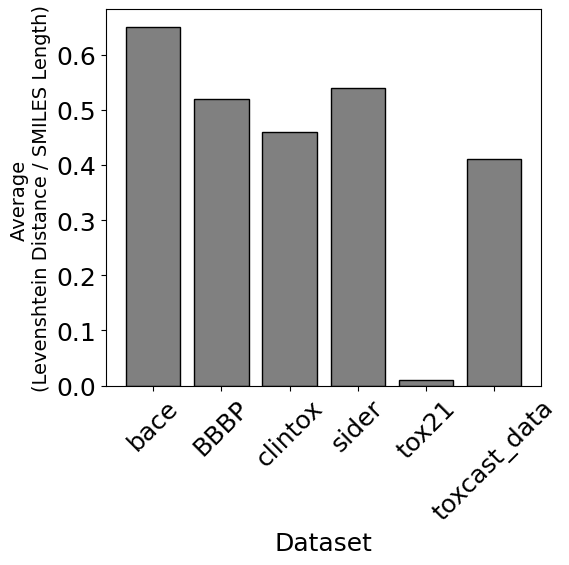

In [19]:
#Fig S1-b
import pandas as pd
import Levenshtein
import numpy as np
import matplotlib.pyplot as plt

files = ["bace","BBBP","clintox","sider","tox21","toxcast_data"]

summary = []
for file1 in files:
    df1 = pd.read_csv("/workspace/MoleculeNet/MoleculeNet_raw/"+file1+".csv",header=None,names=["smiles"])
    df2 = pd.read_csv("/workspace/MoleculeNet/MoleculeNet_standardized/"+file1+".csv",header=None,names=["smiles"])

    df_concat = pd.concat([df1, df2], axis=1)

    df_concat.columns = ["smiles_old", "smiles_new"]

    distances = [
        Levenshtein.distance(str(a), str(b))
        for a, b in zip(df1["smiles"], df2["smiles"])
    ]

    df_concat["levenshtein_distance"] = distances

    normalized_distances = [
        d / max(len(str(a)), len(str(b))) if max(len(str(a)), len(str(b))) > 0 else 0
        for d, a, b in zip(distances, df1["smiles"], df2["smiles"])
    ]

    df_concat["normalized_levenshtein"] = normalized_distances

    max_dist = np.max(normalized_distances)
    min_dist = np.min(normalized_distances)
    mean_dist = np.mean(normalized_distances)
    std_dist = np.std(normalized_distances)

    summary.append({
        "input_file": file1,
        "max_distance": max_dist,
        "min_distance": min_dist,
        "mean_distance": round(mean_dist, 2),
        "std_distance": round(std_dist, 2)
    })
    max_index = np.argmax(distances)
    drug_max = df1["smiles"].iloc[max_index]
    smiles_max = df2["smiles"].iloc[max_index]

summary_df = pd.DataFrame(summary)
#summary_df.to_csv("levenshtein_summary_Mol.csv", index=False)


df_selected = summary_df[summary_df["input_file"].isin(files)]
df_selected["input_file"] = pd.Categorical(df_selected["input_file"], categories=files, ordered=True)
df_selected = df_selected.sort_values("input_file")


plt.figure(figsize=(6, 6))
plt.bar(
    df_selected["input_file"],
    df_selected["mean_distance"],
    capsize=5,  
    color="gray",
    edgecolor="black"
)
plt.rcParams["font.size"] = 18
plt.xlabel("Dataset")
plt.ylabel("Average \n(Levenshtein Distance / SMILES Length)",fontsize=14)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

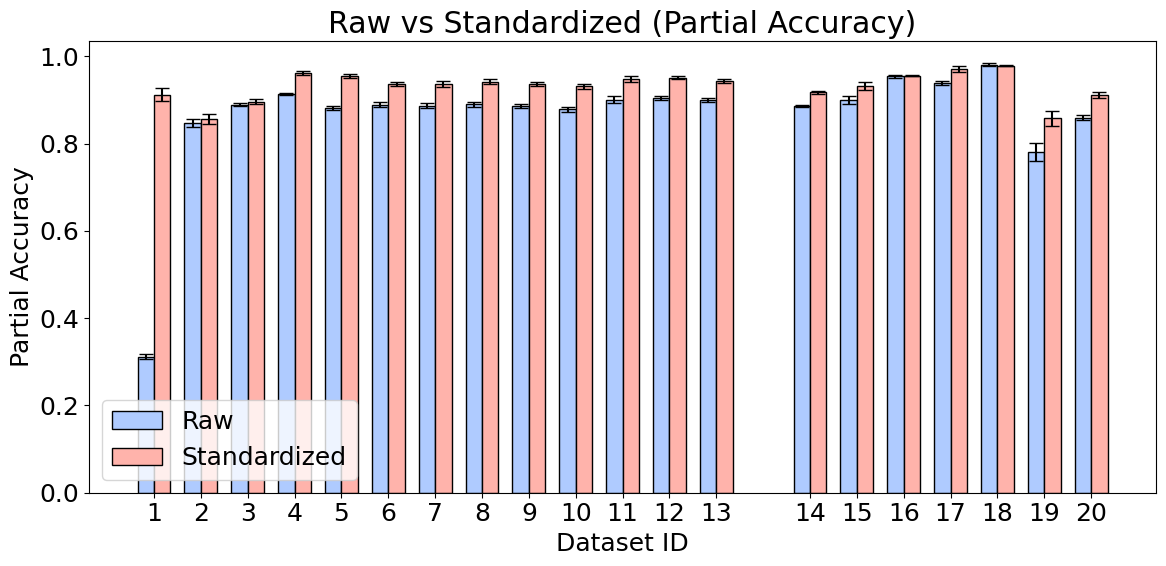

In [13]:
#Fig S1-c
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

eff =[]
ci_l = []
ci_u = []
dif = []
# データの定義
dfa= pd.read_csv("/workspace/2406_paper/output2.csv")
dfb= pd.read_csv("/workspace/2406_paper/output_ADME.csv")

dfs = pd.concat([dfa,dfb])
df1 = dfs[(dfs["Data"] == "n") & (dfs["hue"] == "no")]

df2 = dfs[(dfs["Data"] == "n") & (dfs["hue"] == "n")]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ADME_Tox = ["2_PAMPA_NCATS","3_HIA_Hou","4_Pgp_Broccatelli","5_Bioavailability_Ma","9_BBB_Martins","12_CYP2C19_Veith","13_CYP2D6_Veith","14_CYP3A4_Veith","15_CYP1A2_Veith","16_CYP2C9_Veith", "17_CYP2C9_Substrate_CarbonMangels","18_CYP2D6_Substrate_CarbonMangels","19_CYP3A4_Substrate_CarbonMangels","2_hERG","4_hERG_Karim","5_AMES","6_DILI","7_Skin Reaction","8_Carcinogens_Lagunin","11_ClinTox"]

raw_means = []
std_means = []
raw_stds = []
std_stds = []

for mol in ADME_Tox:
    raw_scores = df1[df1["kind"] == mol]["A"]
    std_scores = df2[df2["kind"] == mol]["A"]

    raw_means.append(np.mean(raw_scores))
    std_means.append(np.mean(std_scores))
    raw_stds.append(np.std(raw_scores))
    std_stds.append(np.std(std_scores))

n = len(ADME_Tox)

x = np.arange(1, n + 1)
x_adjusted = np.array([xi if xi <= 13 else xi + 1 for xi in x])

width = 0.35 

fig, ax = plt.subplots(figsize=(12, 6))


bars1 = ax.bar(x_adjusted - width/2, raw_means, width, yerr=raw_stds, label='Raw',
               color='#AFCBFF', edgecolor='black', capsize=5)
bars2 = ax.bar(x_adjusted + width/2, std_means, width, yerr=std_stds, label='Standardized',
               color='#FFB3AB', edgecolor='black', capsize=5)
plt.rcParams["font.size"] = 18

ax.set_ylabel('Partial Accuracy')
ax.set_xlabel('Dataset ID')
ax.set_title('Raw vs Standardized (Partial Accuracy)')
ax.set_xticks(x_adjusted)
ax.set_xticklabels(np.arange(1, n + 1))  # 表示ラベルは 1～n のまま

ax.legend()
plt.tight_layout()
plt.show()

## Figure S4 Score Differences Between Models Trained on Latent Representations Derived from Raw and Standardized SMILES

* S4-a Plots of AUROC scores (MoleculeNet)

* S4-b Bar plots of AUROC scores (TDC)

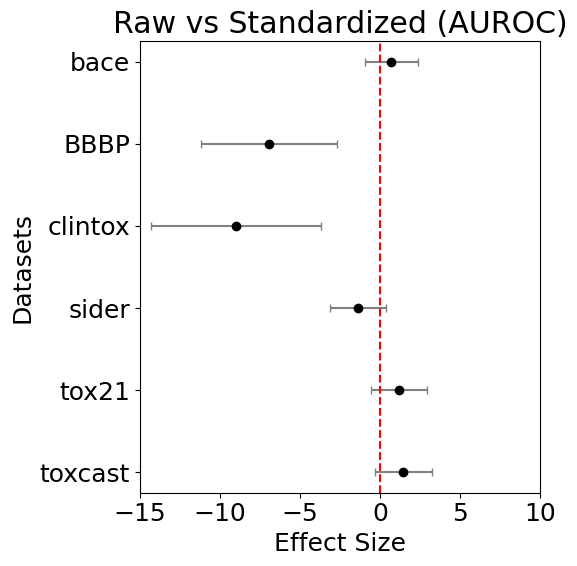

In [25]:
#Fig S4-a
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/workspace/2406_paper/downstream.csv")

data_long = []
for i in range(1, 4):
    for index, row in df.iterrows():
        data_long.append({
            'Dataset': row['data'],
            'Type': 'Raw',
            'Model': f'Model_{i}',
            'Value': row[f'no{i}']
        })
        data_long.append({
            'Dataset': row['data'],
            'Type': 'Standardized',
            'Model': f'Model_{i}',
            'Value': row[f'n{i}']
        })

df_long = pd.DataFrame(data_long)

eff = []
ci_l = []
ci_u = []
datasets = []

grouped = df_long.groupby('Dataset')
for name, group in grouped:
    raw = group[group['Type'] == 'Raw']['Value'].values
    std = group[group['Type'] == 'Standardized']['Value'].values

    if len(raw) == 0 or len(std) == 0:
        continue

    mean_raw = np.mean(raw)
    mean_std = np.mean(std)
    std_raw = np.std(raw, ddof=1)
    std_std = np.std(std, ddof=1)
    n_raw = len(raw)
    n_std = len(std)

    pooled_std = np.sqrt(((n_raw - 1) * std_raw ** 2 + (n_std - 1) * std_std ** 2) / (n_raw + n_std - 2))

    d = (mean_std - mean_raw) / pooled_std

    se = np.sqrt((n_raw + n_std) / (n_raw * n_std) + d ** 2 / (2 * (n_raw + n_std)))
    ci_lower = d - 1.96 * se
    ci_upper = d + 1.96 * se

    eff.append(d)
    ci_l.append(ci_lower)
    ci_u.append(ci_upper)
    datasets.append(name)

df_plot = pd.DataFrame({
    'Dataset': datasets,
    'Effect Size': eff,
    'Lower CI': ci_l,
    'Upper CI': ci_u
}).iloc[::-1]
ordered_datasets = ["bace", "BBBP", "clintox", "sider", "tox21", "toxcast"]
df_plot['Dataset'] = pd.Categorical(df_plot['Dataset'], categories=ordered_datasets, ordered=True)
df_plot = df_plot.sort_values('Dataset', ascending=False) 


fig, (ax1) = plt.subplots(1, 1, sharey=True, figsize=(6, 6))
fig.subplots_adjust(wspace=0.01)
plt.rcParams["font.size"] = 18

ax1.errorbar(df_plot['Effect Size'], df_plot['Dataset'],
             xerr=[df_plot['Effect Size'] - df_plot['Lower CI'], df_plot['Upper CI'] - df_plot['Effect Size']],
             fmt='o', color='black', ecolor='gray', capsize=3)
ax1.axvline(0, color='red', linestyle='--')
ax1.set_xlim(-15, 10)
ax1.set_xlabel("Effect Size")
ax1.set_ylabel("Datasets")
ax1.tick_params(axis='x')
ax1.set_title('Raw vs Standardized (AUROC)')

plt.tight_layout()
plt.show()


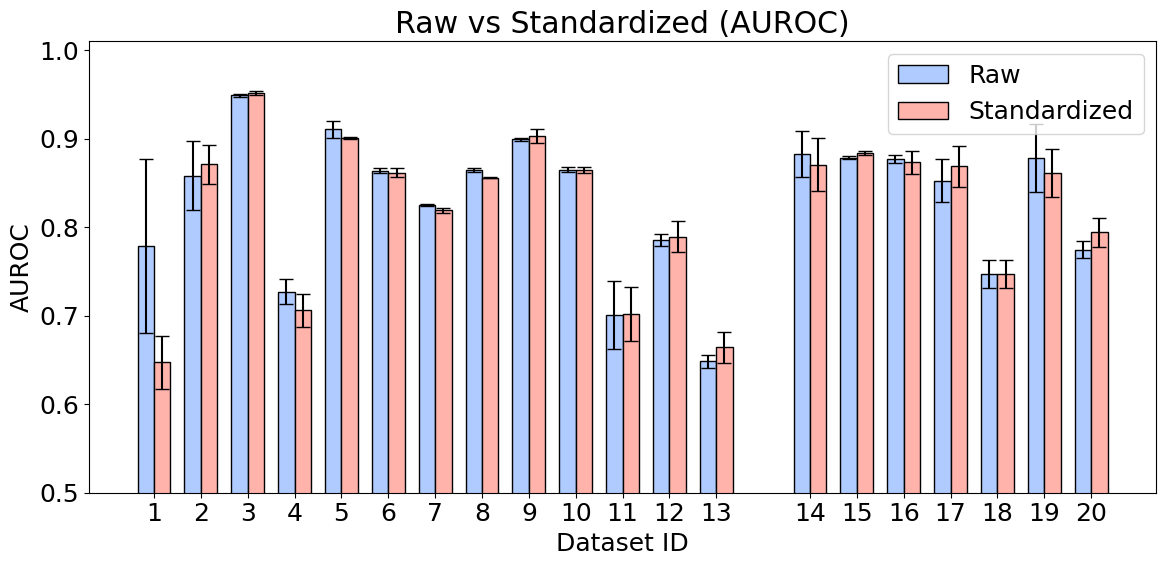

In [64]:
#Fig S4-b
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

eff =[]
ci_l = []
ci_u = []
dif = []

dfa= pd.read_csv("/workspace/2406_paper/n_no.csv")
dfb= pd.read_csv("/workspace/2406_paper/ADME_pre.csv")
dfs = pd.concat([dfa,dfb])
df1 = dfs[(dfs["Data"] == "n") & (dfs["hue"] == "no")]

df2 = dfs[(dfs["Data"] == "n") & (dfs["hue"] == "n")]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ADME_Tox = ["2_PAMPA_NCATS","3_HIA_Hou","4_Pgp_Broccatelli","5_Bioavailability_Ma","9_BBB_Martins","12_CYP2C19_Veith","13_CYP2D6_Veith","14_CYP3A4_Veith","15_CYP1A2_Veith","16_CYP2C9_Veith", "17_CYP2C9_Substrate_CarbonMangels","18_CYP2D6_Substrate_CarbonMangels","19_CYP3A4_Substrate_CarbonMangels","2_hERG","4_hERG_Karim","5_AMES","6_DILI","7_Skin Reaction","8_Carcinogens_Lagunin","11_ClinTox"]

raw_means = []
std_means = []
raw_stds = []
std_stds = []

for mol in ADME_Tox:
    raw_scores = df1[df1["kind"] == mol]["A"]
    std_scores = df2[df2["kind"] == mol]["A"]

    raw_means.append(np.mean(raw_scores))
    std_means.append(np.mean(std_scores))
    raw_stds.append(np.std(raw_scores))
    std_stds.append(np.std(std_scores))

import numpy as np
import matplotlib.pyplot as plt

n = len(ADME_Tox)

x = np.arange(1, n + 1)
x_adjusted = np.array([xi if xi <= 13 else xi + 1 for xi in x])

width = 0.35  # 棒の幅
plt.rcParams["font.size"] = 18
fig, ax = plt.subplots(figsize=(12, 6))


bars1 = ax.bar(x_adjusted - width/2, raw_means, width, yerr=raw_stds, label='Raw',
               color='#AFCBFF', edgecolor='black', capsize=5)
bars2 = ax.bar(x_adjusted + width/2, std_means, width, yerr=std_stds, label='Standardized',
               color='#FFB3AB', edgecolor='black', capsize=5)

ax.set_ylabel('AUROC')
ax.set_xlabel('Dataset ID')
ax.set_title('Raw vs Standardized (AUROC)')
ax.set_xticks(x_adjusted)
ax.set_xticklabels(np.arange(1, n + 1))  # 表示ラベルは 1～n のまま
ax.set_ylim(0.5, 1.01)
ax.legend()
plt.tight_layout()
plt.show()


## Supplementary Figure 5 Impact of Kekulé/Aromatic Notational Mismatch on Predictive Performance on the BBBP Dataset

* S5-a Distribution of positive and negative labels in the BBBP dataset

* S5-b ROC curve for the model trained on Raw SMILES in the BBBP dataset

* S5-c Running sum plot demonstrating the enrichment of K/A mismatch compounds at the early region of the ROC curve

[22:18:04] WARNING: not removing hydrogen atom without neighbors
[22:18:04] WARNING: not removing hydrogen atom without neighbors
[22:18:04] WARNING: not removing hydrogen atom without neighbors
[22:18:04] WARNING: not removing hydrogen atom without neighbors
[22:18:04] WARNING: not removing hydrogen atom without neighbors


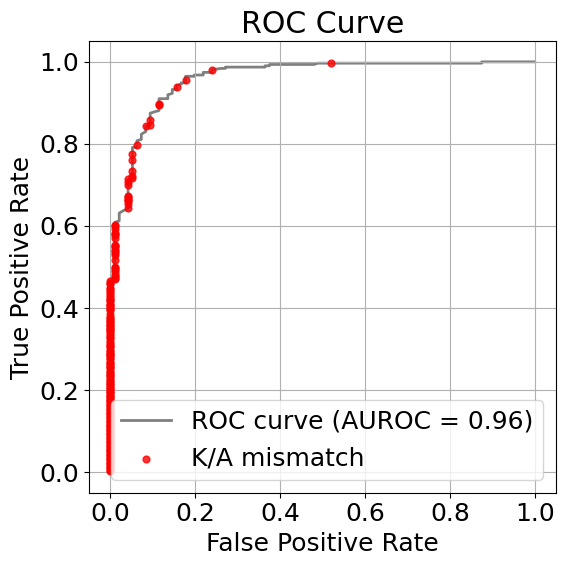

In [20]:
#Fig S5-b
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
from rdkit import Chem
import matplotlib.patches as mpatches

df = pd.read_csv("/workspace/2406_paper/BBBP_predict.csv")

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

df["canonical_smiles"] = df["smiles"].apply(canonicalize)

df["is_variation"] = (
    ~df["smiles"].str.contains("c", case=True, na=False) &
     df["canonical_smiles"].str.contains("c", case=True, na=False)
)

y_true = df["Y"]
y_score = df["predict"]
is_variation = df["is_variation"]

y_true = np.array(y_true)
y_score = np.array(y_score)
is_variation = np.array(is_variation)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

sorted_indices = np.argsort(-y_score)
y_true_sorted = y_true[sorted_indices]
y_score_sorted = y_score[sorted_indices]
is_variation_sorted = is_variation[sorted_indices]

fpr_points = []
tpr_points = []
colors = []

tp = 0
fp = 0
P = sum(y_true)
N = len(y_true) - P

fpr_points = []
tpr_points = []
highlight_fpr = []
highlight_tpr = []

for i in range(len(y_true_sorted)):
    if y_true_sorted[i] == 1:
        tp += 1
    else:
        fp += 1
    fpr_i = fp / N
    tpr_i = tp / P
    fpr_points.append(fpr_i)
    tpr_points.append(tpr_i)

    if is_variation_sorted[i]:
        highlight_fpr.append(fpr_i)
        highlight_tpr.append(tpr_i)

plt.rcParams["font.size"] = 18

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='gray', lw=2, label=f'ROC curve (AUROC = {roc_auc:.2f})',zorder=1)
plt.scatter(highlight_fpr, highlight_tpr, c='red', s=24,alpha=0.8, label='K/A mismatch',zorder=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[22:18:45] WARNING: not removing hydrogen atom without neighbors
[22:18:45] WARNING: not removing hydrogen atom without neighbors
[22:18:45] WARNING: not removing hydrogen atom without neighbors
[22:18:45] WARNING: not removing hydrogen atom without neighbors
[22:18:45] WARNING: not removing hydrogen atom without neighbors


{'D': 0.3877870053737177, 'D_signed': 0.3877870053737177, 'argmax': 233, 'n_pos': 178, 'n_neg': 230}


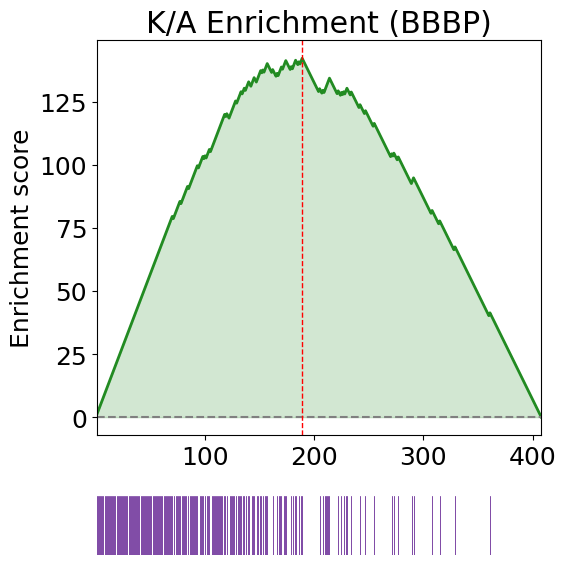

{'D': 142.24828847480282,
 'D_signed': 142.24828847480282,
 'argmax': 188,
 'n_pos': 178,
 'n_neg': 230}

In [21]:
#Fig S5-c
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score, roc_curve, auc
import pandas as pd
from rdkit import Chem

def _validate_inputs(weights: np.ndarray, ka_binary: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Validate and align input vectors."""
    w = np.asarray(weights, dtype=float).ravel()
    b = np.asarray(ka_binary, dtype=int).ravel()
    if w.shape[0] != b.shape[0]:
        raise ValueError(f"Length mismatch: weights={w.shape[0]}, ka_binary={b.shape[0]}")
    if np.any(~np.isfinite(w)):
        raise ValueError("weights contain non-finite values")
    if np.any((b != 0) & (b != 1)):
        raise ValueError("ka_binary must be a binary vector of 0/1")
    return w, b

def ks_statistic_sorted(weights: np.ndarray, ka_binary: np.ndarray) -> Dict[str, float]:
    """
    Compute KS statistic after sorting by weights (descending).

    Parameters
    ----------
    weights : array-like of shape (n_samples,)
        Per-sample weights (e.g., AUROC contributions). Larger means more important.
    ka_binary : array-like of shape (n_samples,)
        Binary indicator for K/A mismatch (1 = mismatch, 0 = no mismatch).

    Returns
    -------
    dict with keys:
        D : KS statistic (max absolute difference)
        D_signed : Signed KS (positive if K/A enriched at top)
        argmax : index (in sorted order) where |diff| is maximized
        n_pos : number of K/A=1 samples
        n_neg : number of K/A=0 samples
    """
    w, b = _validate_inputs(weights, ka_binary)

    # Sort by weights descending
    order = np.argsort(-w)
    b_sorted = b[order]

    # Empirical CDFs as we move down the ranked list
    n = b_sorted.size
    n_pos = b_sorted.sum()
    n_neg = n - n_pos
    if n_pos == 0 or n_neg == 0:
        raise ValueError("Both classes must be present (need some 0s and some 1s).")

    # Cumulative counts for positives and negatives
    cum_pos = np.cumsum(b_sorted) / n_pos
    cum_neg = np.cumsum(1 - b_sorted) / n_neg

    diff = cum_pos - cum_neg
    argmax = int(np.argmax(np.abs(diff)))
    D = float(np.abs(diff[argmax]))
    D_signed = float(diff[argmax])

    return {
        "D": D,
        "D_signed": D_signed,
        "argmax": argmax,
        "n_pos": int(n_pos),
        "n_neg": int(n_neg),
    }

def plot_running_sum(contribs_sorted, is_variation_sorted, perm,
                     title="K/A Enrichment (BBBP)", 
                     color="forestgreen", alpha=0.2, 
                     barcode_color="indigo", barcode_size=0.15,
                     xlabel="Rank in ordered samples", 
                     ylabel="Enrichment score", 
                     figsize=(6,6), dpi=100, fileout=None):
    """
    Plot running sum enrichment plot (GSEA-style) with barcode tracks.

    Parameters
    ----------
    contribs_sorted : 1d array-like
        Sorted contributions (descending).
    is_variation_sorted : 1d array-like (binary)
        Sorted binary vector (1 = variation, 0 = otherwise).
    title : str
        Plot title.
    color : str
        Color of enrichment curve.
    alpha : float
        Transparency for filled area under curve.
    barcode_color : str
        Color for barcode ticks.
    barcode_size : float
        Relative size of barcode track.
    xlabel, ylabel : str
        Axis labels.
    figsize : tuple
        Figure size.
    dpi : int
        Figure resolution.
    fileout : str or None
        If provided, save to file.
    """

    contribs_sorted = np.array(contribs_sorted)
    is_variation_sorted = np.array(is_variation_sorted).astype(bool)
    n = len(contribs_sorted)

    # enrichment curve (running sum, KS-style)
    n_pos = is_variation_sorted.sum()
    n_neg = n - n_pos
    inc = np.sqrt(n_neg/n_pos) if n_pos > 0 else 0
    dec = -np.sqrt(n_pos/n_neg) if n_neg > 0 else 0
    running = np.cumsum(np.where(is_variation_sorted, inc, dec))
    x = np.arange(1, n+1)

    # max deviation
    argmax = np.argmax(np.abs(running))
    D_signed = running[argmax]

    # layout
    fig = plt.figure(figsize=figsize, dpi=dpi)
    spec = gridspec.GridSpec(ncols=1, nrows=2, height_ratios=[1, barcode_size])

    # main axis
    ax = fig.add_subplot(spec[0,0])
    ax.plot(x, running, color=color, lw=2)
    ax.fill_between(x, 0, running, color=color, alpha=alpha)
    ax.axhline(0, color="gray", ls="--")
    ax.axvline(x[argmax], color="red", ls="--", lw=1)
    ax.set_ylabel(ylabel)
    ax.set_xlim(1, n)
    ax.set_title(title)

    # barcode axis
    axb = fig.add_subplot(spec[1,0], sharex=ax)
    ylim = [-1, 1]
    for i, l in enumerate(is_variation_sorted):
        if l:
            axb.plot([x[i], x[i]], ylim, color=barcode_color, lw=0.5)
    axb.set_ylim(ylim)
    axb.set_xlabel(xlabel)
    axb.axis("off")
    plt.tight_layout()

    if fileout:
        plt.savefig(fileout, bbox_inches="tight", dpi=dpi)
    plt.show()

    return {"D": abs(D_signed), "D_signed": D_signed, "argmax": argmax, "n_pos": n_pos, "n_neg": n_neg}


def loo_auroc_contributions(y_true, y_score):
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    
    full_auroc = roc_auc_score(y_true, y_score)
    
    contributions = np.zeros(len(y_true))
    
    for i in range(len(y_true)):
        mask = np.ones(len(y_true), dtype=bool)
        mask[i] = False
        
        try:
            loo_auroc = roc_auc_score(y_true[mask], y_score[mask])
            contributions[i] = full_auroc - loo_auroc
        except ValueError:
            contributions[i] = np.nan
    
    return contributions

df = pd.read_csv("/workspace/2406_paper/BBBP_predict.csv")

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

df["canonical_smiles"] = df["smiles"].apply(canonicalize)

df["is_variation"] = (
    ~df["smiles"].str.contains("c", case=True, na=False) &
     df["canonical_smiles"].str.contains("c", case=True, na=False)
)

y_true = df["Y"]
y_score = df["predict"]
is_variation = df["is_variation"]

contribs = loo_auroc_contributions(y_true, y_score)
df["contribs"] = contribs
plt.rcParams["font.size"] = 18

order = np.argsort(-y_score)

contribs_sorted = contribs[order]
is_variation_sorted = is_variation[order]

res = ks_statistic_sorted(contribs_sorted, is_variation_sorted)
print(res)  # {"D": ..., "D_signed": ..., "argmax": ..., "n_pos": ..., "n_neg": ...}

plot_running_sum(contribs_sorted, is_variation_sorted,perm)

## Supplementary Figure 7. Impacts of Stereochemical Annotations on Translation Tasks

* S7-a Bar plot showing translation accuracy of MTMs using Standardized, 3D-added and 3D-removed SMILES

* S7-b,c,d Bar plots showing the frequencies of the top 10 translation errors

* S7-e resentative examples of reconstruction errors

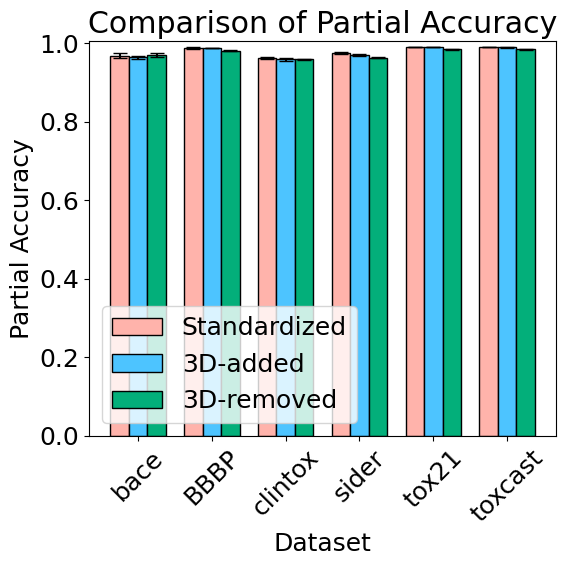

In [69]:
#Fig S7-a
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 18
Mol = ["bace", "BBBP", "clintox", "sider", "tox21", "toxcast"]
x = np.arange(len(Mol)) 
width = 0.25 

dfs_add = pd.read_csv("/workspace/2406_paper/summary_with_params3.csv")
dfs_rem = pd.read_csv("/workspace/2406_paper/summary_with_params2.csv")

df_std_add = dfs_add[(dfs_add["Param_3"] == "n") & (dfs_add["Param_5"] == "n")]
df_add = dfs_add[(dfs_add["Param_3"] == "p") & (dfs_add["Param_5"] == "p")]

df_std_rem = dfs_rem[(dfs_rem["Param_3"] == "n") & (dfs_rem["Param_5"] == "n")]
df_rem = dfs_rem[(dfs_rem["Param_3"] == "r") & (dfs_rem["Param_5"] == "r")]

std_means = []
add_means = []
rem_means = []
std_stds = []
add_stds = []
rem_stds = []

for mol in Mol:
    std_scores_add = df_std_add[df_std_add["Param_6"] == mol]["Partial accuracy"]
    add_scores = df_add[df_add["Param_6"] == mol]["Partial accuracy"]
    std_scores_rem = df_std_rem[df_std_rem["Param_6"] == mol]["Partial accuracy"]
    rem_scores = df_rem[df_rem["Param_6"] == mol]["Partial accuracy"]

    std_means.append(np.mean(std_scores_add))
    add_means.append(np.mean(add_scores))
    rem_means.append(np.mean(rem_scores))

    std_stds.append(np.std(std_scores_add))
    add_stds.append(np.std(add_scores))
    rem_stds.append(np.std(rem_scores))

fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(x - width, std_means, width, yerr=std_stds, label='Standardized',
       color='#FFB3AB', edgecolor='black', capsize=5)
ax.bar(x, add_means, width, yerr=add_stds, label='3D-added',
       color='#4DC4FF', edgecolor='black', capsize=5)
ax.bar(x + width, rem_means, width, yerr=rem_stds, label='3D-removed',
       color='#03AF7A', edgecolor='black', capsize=5)

ax.set_ylabel('Partial Accuracy')
ax.set_xlabel('Dataset')
ax.set_title('Comparison of Partial Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(Mol, rotation=45)
ax.set_ylim(0.0, 1.005)
ax.legend()

plt.tight_layout()
plt.show()


{'<padding>': 0, '<start>': 1, '<end>': 2, '[Si': 3, '[Sc': 4, '[Ni': 5, '[In': 6, '[Sn': 7, '@@': 8, 'He': 9, 'Li': 10, 'Be': 11, 'Ne': 12, 'Na': 13, 'Mg': 14, 'Al': 15, 'Cl': 16, 'Ar': 17, 'Ca': 18, 'Ti': 19, 'Cr': 20, 'Mn': 21, 'Fe': 22, 'Co': 23, 'Cu': 24, 'Zn': 25, 'Ga': 26, 'Ge': 27, 'As': 28, 'Se': 29, 'Br': 30, 'Kr': 31, 'Rb': 32, 'Sr': 33, 'Zr': 34, 'Nb': 35, 'Mo': 36, 'Tc': 37, 'Ru': 38, 'Rh': 39, 'Pd': 40, 'Ag': 41, 'Cd': 42, 'Sb': 43, 'Te': 44, 'Xe': 45, 'Cs': 46, 'Ba': 47, 'La': 48, 'Ce': 49, 'Pr': 50, 'Nd': 51, 'Pm': 52, 'Sm': 53, 'Eu': 54, 'Gd': 55, 'Tb': 56, 'Dy': 57, 'Ho': 58, 'Er': 59, 'Tm': 60, 'Yb': 61, 'Lu': 62, 'Hf': 63, 'Ta': 64, 'Re': 65, 'Os': 66, 'Ir': 67, 'Pt': 68, 'Au': 69, 'Hg': 70, 'Tl': 71, 'Pb': 72, 'Bi': 73, 'Po': 74, 'At': 75, 'Rn': 76, 'Fr': 77, 'Ra': 78, 'Ac': 79, 'Th': 80, 'Pa': 81, 'se': 82, 'te': 83, '0': 84, '1': 85, '2': 86, '3': 87, '4': 88, '5': 89, '6': 90, '7': 91, '8': 92, '9': 93, '(': 94, ')': 95, '[': 96, ']': 97, ':': 98, '=': 99, '@': 

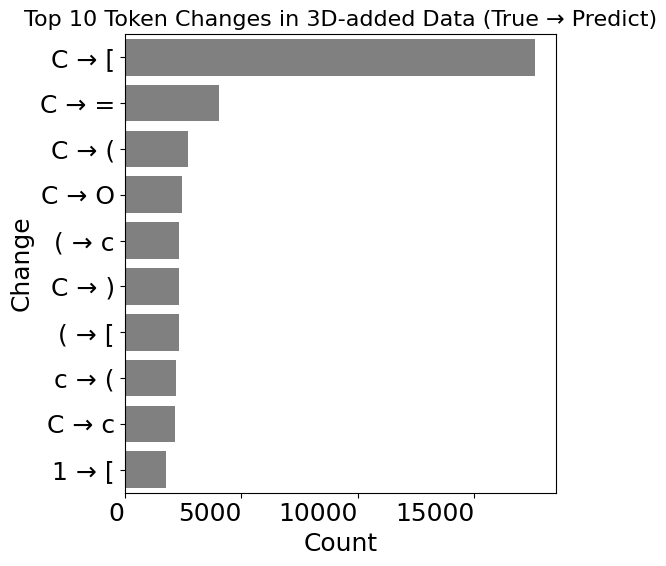

In [27]:
#Fig S7-b
from collections import Counter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

class VocabularyTokenizer():
    def __init__(self, vocs):
        """
        Parameters
        ----------
        vocs: array-like of str
        """
        vocs = sorted(list(vocs), key=lambda x:len(x), reverse=True)
        vocs_with_specials = ['<padding>', '<start>', '<end>'] + vocs
        self.voc_lens = np.sort(np.unique([len(voc) for voc in vocs]))[::-1]
        self.min_voc_len = self.voc_lens[-1]
        self.pad_token = 0
        self.start_token = 1
        self.end_token = 2
        self.voc2tok = {voc: tok for tok, voc in enumerate(vocs_with_specials)}
        print(self.voc2tok)
        self.tok2voc = np.array(vocs_with_specials)

    def tokenize(self, string):
        string_left = string
        toks = [self.start_token]
        while len(string_left) > 0:
            for voc_len in self.voc_lens:
                if string_left[:voc_len] in self.voc2tok:
                    toks.append(self.voc2tok[string_left[:voc_len]])
                    string_left = string_left[voc_len:]
                    break
                if voc_len == self.min_voc_len:
                    raise KeyError(f"Unknown keyward '{string_left}' in {string}")
        toks.append(self.end_token)
        return toks

    def detokenize(self, toks):
        """
        Parameters
        ----------
        toks: array_like of int

        Returns
        -------
        string: str
            detokenized string.
        """
        string = ""
        for tok in toks:
            if tok == self.end_token:
                break
            elif tok != self.start_token:
                string += self.tok2voc[tok]
        return string

    @property
    def voc_size(self):
        return len(self.tok2voc)
        
df = pd.read_csv("/workspace/2403_SMARTS/tox_reset.csv")
df2 = pd.read_csv("/workspace/2403_SMARTS/tox_normal.csv")
df3 = pd.read_csv("/workspace/2403_SMARTS/tox_processed.csv")
df4 = pd.read_csv("/workspace/2403_SMARTS/tox_processed_normal.csv")
c=pd.read_csv("/workspace/2406_paper/large_vocs_true.csv")
mapping = {'<padding>': 0, '<start>': 1, '<end>': 2, '[Si': 3, '[Sc': 4, '[Ni': 5, '[In': 6, '[Sn': 7, '@@': 8, 'He': 9, 'Li': 10, 'Be': 11, 'Ne': 12, 'Na': 13, 'Mg': 14, 'Al': 15, 'Cl': 16, 'Ar': 17, 'Ca': 18, 'Ti': 19, 'Cr': 20, 'Mn': 21, 'Fe': 22, 'Co': 23, 'Cu': 24, 'Zn': 25, 'Ga': 26, 'Ge': 27, 'As': 28, 'Se': 29, 'Br': 30, 'Kr': 31, 'Rb': 32, 'Sr': 33, 'Zr': 34, 'Nb': 35, 'Mo': 36, 'Tc': 37, 'Ru': 38, 'Rh': 39, 'Pd': 40, 'Ag': 41, 'Cd': 42, 'Sb': 43, 'Te': 44, 'Xe': 45, 'Cs': 46, 'Ba': 47, 'La': 48, 'Ce': 49, 'Pr': 50, 'Nd': 51, 'Pm': 52, 'Sm': 53, 'Eu': 54, 'Gd': 55, 'Tb': 56, 'Dy': 57, 'Ho': 58, 'Er': 59, 'Tm': 60, 'Yb': 61, 'Lu': 62, 'Hf': 63, 'Ta': 64, 'Re': 65, 'Os': 66, 'Ir': 67, 'Pt': 68, 'Au': 69, 'Hg': 70, 'Tl': 71, 'Pb': 72, 'Bi': 73, 'Po': 74, 'At': 75, 'Rn': 76, 'Fr': 77, 'Ra': 78, 'Ac': 79, 'Th': 80, 'Pa': 81, 'se': 82, 'te': 83, '0': 84, '1': 85, '2': 86, '3': 87, '4': 88, '5': 89, '6': 90, '7': 91, '8': 92, '9': 93, '(': 94, ')': 95, '[': 96, ']': 97, ':': 98, '=': 99, '@': 100, '+': 101, '/': 102, '\\': 103, '.': 104, '-': 105, '#': 106, '%': 107, 'c': 108, 'i': 109, 'o': 110, 'n': 111, 'p': 112, 's': 113, 'b': 114, 'H': 115, 'B': 116, 'C': 117, 'N': 118, 'O': 119, 'F': 120, 'P': 121, 'S': 122, 'K': 123, 'V': 124, 'Y': 125, 'I': 126, 'W': 127, 'U': 128}
Token = VocabularyTokenizer(vocs=c["voc"])

all_elements = set()

for fi in [df,df2,df3,df4]:
    for i in range(len(fi)):
        all_elements.update(Token.tokenize(fi.loc[i, 'predict']))
        all_elements.update(Token.tokenize(fi.loc[i, 'true']))

filtered_mapping = {key: value for key, value in mapping.items() if value in all_elements}
filtered_values = [value for value in filtered_mapping.values() ]
 
total_diff_count = Counter()

reverse_mapping = {v: k for k, v in filtered_mapping.items()}

for i in range(len(df4)):
    base_value = df4.loc[i, 'predict']
    compare_value = df4.loc[i, 'true']
    
    k = Token.tokenize(base_value)
    l = Token.tokenize(compare_value)
    differences = []


    for a, b in zip(k, l):
        if a - b != 0:
            differences.append((reverse_mapping[a], reverse_mapping[b]))
            
    total_diff_count.update(differences)
    

top_diffs = total_diff_count.most_common(10)

before_tokens = [pair[0][0] for pair in top_diffs]
after_tokens = [pair[0][1] for pair in top_diffs]
counts = [pair[1] for pair in top_diffs]

df_plot = pd.DataFrame({
    'Change': [f'{a} → {b}' for b, a in zip(before_tokens, after_tokens)],
    'Before': before_tokens,
    'After': after_tokens,
    'Count': counts
})
plt.rcParams["font.size"] = 18

plt.figure(figsize=(6, 6))
ax = sns.barplot(y='Change', x='Count', data=df_plot, color="gray")

plt.title('Top 10 Token Changes in 3D-added Data (True → Predict)',fontsize=16)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

{'<padding>': 0, '<start>': 1, '<end>': 2, '[Si': 3, '[Sc': 4, '[Ni': 5, '[In': 6, '[Sn': 7, '@@': 8, 'He': 9, 'Li': 10, 'Be': 11, 'Ne': 12, 'Na': 13, 'Mg': 14, 'Al': 15, 'Cl': 16, 'Ar': 17, 'Ca': 18, 'Ti': 19, 'Cr': 20, 'Mn': 21, 'Fe': 22, 'Co': 23, 'Cu': 24, 'Zn': 25, 'Ga': 26, 'Ge': 27, 'As': 28, 'Se': 29, 'Br': 30, 'Kr': 31, 'Rb': 32, 'Sr': 33, 'Zr': 34, 'Nb': 35, 'Mo': 36, 'Tc': 37, 'Ru': 38, 'Rh': 39, 'Pd': 40, 'Ag': 41, 'Cd': 42, 'Sb': 43, 'Te': 44, 'Xe': 45, 'Cs': 46, 'Ba': 47, 'La': 48, 'Ce': 49, 'Pr': 50, 'Nd': 51, 'Pm': 52, 'Sm': 53, 'Eu': 54, 'Gd': 55, 'Tb': 56, 'Dy': 57, 'Ho': 58, 'Er': 59, 'Tm': 60, 'Yb': 61, 'Lu': 62, 'Hf': 63, 'Ta': 64, 'Re': 65, 'Os': 66, 'Ir': 67, 'Pt': 68, 'Au': 69, 'Hg': 70, 'Tl': 71, 'Pb': 72, 'Bi': 73, 'Po': 74, 'At': 75, 'Rn': 76, 'Fr': 77, 'Ra': 78, 'Ac': 79, 'Th': 80, 'Pa': 81, 'se': 82, 'te': 83, '0': 84, '1': 85, '2': 86, '3': 87, '4': 88, '5': 89, '6': 90, '7': 91, '8': 92, '9': 93, '(': 94, ')': 95, '[': 96, ']': 97, ':': 98, '=': 99, '@': 

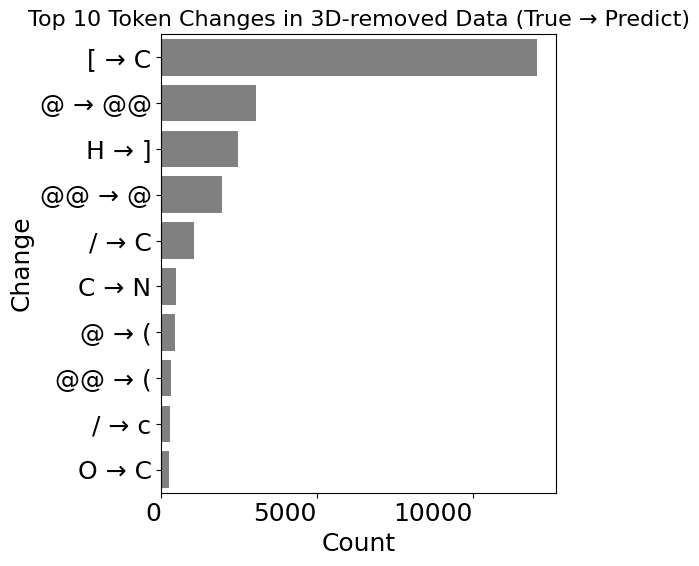

In [28]:
#Fig S7-c
from collections import Counter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/workspace/2403_SMARTS/tox_reset.csv")
df2 = pd.read_csv("/workspace/2403_SMARTS/tox_normal.csv")
df3 = pd.read_csv("/workspace/2403_SMARTS/tox_processed.csv")
df4 = pd.read_csv("/workspace/2403_SMARTS/tox_reset_normal.csv")
c=pd.read_csv("/workspace/2406_paper/large_vocs_true.csv")
mapping = {'<padding>': 0, '<start>': 1, '<end>': 2, '[Si': 3, '[Sc': 4, '[Ni': 5, '[In': 6, '[Sn': 7, '@@': 8, 'He': 9, 'Li': 10, 'Be': 11, 'Ne': 12, 'Na': 13, 'Mg': 14, 'Al': 15, 'Cl': 16, 'Ar': 17, 'Ca': 18, 'Ti': 19, 'Cr': 20, 'Mn': 21, 'Fe': 22, 'Co': 23, 'Cu': 24, 'Zn': 25, 'Ga': 26, 'Ge': 27, 'As': 28, 'Se': 29, 'Br': 30, 'Kr': 31, 'Rb': 32, 'Sr': 33, 'Zr': 34, 'Nb': 35, 'Mo': 36, 'Tc': 37, 'Ru': 38, 'Rh': 39, 'Pd': 40, 'Ag': 41, 'Cd': 42, 'Sb': 43, 'Te': 44, 'Xe': 45, 'Cs': 46, 'Ba': 47, 'La': 48, 'Ce': 49, 'Pr': 50, 'Nd': 51, 'Pm': 52, 'Sm': 53, 'Eu': 54, 'Gd': 55, 'Tb': 56, 'Dy': 57, 'Ho': 58, 'Er': 59, 'Tm': 60, 'Yb': 61, 'Lu': 62, 'Hf': 63, 'Ta': 64, 'Re': 65, 'Os': 66, 'Ir': 67, 'Pt': 68, 'Au': 69, 'Hg': 70, 'Tl': 71, 'Pb': 72, 'Bi': 73, 'Po': 74, 'At': 75, 'Rn': 76, 'Fr': 77, 'Ra': 78, 'Ac': 79, 'Th': 80, 'Pa': 81, 'se': 82, 'te': 83, '0': 84, '1': 85, '2': 86, '3': 87, '4': 88, '5': 89, '6': 90, '7': 91, '8': 92, '9': 93, '(': 94, ')': 95, '[': 96, ']': 97, ':': 98, '=': 99, '@': 100, '+': 101, '/': 102, '\\': 103, '.': 104, '-': 105, '#': 106, '%': 107, 'c': 108, 'i': 109, 'o': 110, 'n': 111, 'p': 112, 's': 113, 'b': 114, 'H': 115, 'B': 116, 'C': 117, 'N': 118, 'O': 119, 'F': 120, 'P': 121, 'S': 122, 'K': 123, 'V': 124, 'Y': 125, 'I': 126, 'W': 127, 'U': 128}
Token = VocabularyTokenizer(vocs=c["voc"])

all_elements = set()

for fi in [df,df2,df3,df4]:
    for i in range(len(fi)):
        all_elements.update(Token.tokenize(fi.loc[i, 'predict']))
        all_elements.update(Token.tokenize(fi.loc[i, 'true']))

filtered_mapping = {key: value for key, value in mapping.items() if value in all_elements}
filtered_values = [value for value in filtered_mapping.values() ]
 
total_diff_count = Counter()

reverse_mapping = {v: k for k, v in filtered_mapping.items()}

for i in range(len(df4)):
    base_value = df4.loc[i, 'predict']
    compare_value = df4.loc[i, 'true']
    
    k = Token.tokenize(base_value)
    l = Token.tokenize(compare_value)
    differences = []


    for a, b in zip(k, l):
        if a - b != 0:
            differences.append((reverse_mapping[a], reverse_mapping[b]))
            
    total_diff_count.update(differences)
    

top_diffs = total_diff_count.most_common(10)

before_tokens = [pair[0][0] for pair in top_diffs]
after_tokens = [pair[0][1] for pair in top_diffs]
counts = [pair[1] for pair in top_diffs]

df_plot = pd.DataFrame({
    'Change': [f'{a} → {b}' for b, a in zip(before_tokens, after_tokens)],
    'Before': before_tokens,
    'After': after_tokens,
    'Count': counts
})
plt.rcParams["font.size"] = 18

plt.figure(figsize=(6, 6))
ax = sns.barplot(y='Change', x='Count', data=df_plot, color="gray")

plt.title('Top 10 Token Changes in 3D-removed Data (True → Predict)',fontsize=16)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

{'<padding>': 0, '<start>': 1, '<end>': 2, '[Si': 3, '[Sc': 4, '[Ni': 5, '[In': 6, '[Sn': 7, '@@': 8, 'He': 9, 'Li': 10, 'Be': 11, 'Ne': 12, 'Na': 13, 'Mg': 14, 'Al': 15, 'Cl': 16, 'Ar': 17, 'Ca': 18, 'Ti': 19, 'Cr': 20, 'Mn': 21, 'Fe': 22, 'Co': 23, 'Cu': 24, 'Zn': 25, 'Ga': 26, 'Ge': 27, 'As': 28, 'Se': 29, 'Br': 30, 'Kr': 31, 'Rb': 32, 'Sr': 33, 'Zr': 34, 'Nb': 35, 'Mo': 36, 'Tc': 37, 'Ru': 38, 'Rh': 39, 'Pd': 40, 'Ag': 41, 'Cd': 42, 'Sb': 43, 'Te': 44, 'Xe': 45, 'Cs': 46, 'Ba': 47, 'La': 48, 'Ce': 49, 'Pr': 50, 'Nd': 51, 'Pm': 52, 'Sm': 53, 'Eu': 54, 'Gd': 55, 'Tb': 56, 'Dy': 57, 'Ho': 58, 'Er': 59, 'Tm': 60, 'Yb': 61, 'Lu': 62, 'Hf': 63, 'Ta': 64, 'Re': 65, 'Os': 66, 'Ir': 67, 'Pt': 68, 'Au': 69, 'Hg': 70, 'Tl': 71, 'Pb': 72, 'Bi': 73, 'Po': 74, 'At': 75, 'Rn': 76, 'Fr': 77, 'Ra': 78, 'Ac': 79, 'Th': 80, 'Pa': 81, 'se': 82, 'te': 83, '0': 84, '1': 85, '2': 86, '3': 87, '4': 88, '5': 89, '6': 90, '7': 91, '8': 92, '9': 93, '(': 94, ')': 95, '[': 96, ']': 97, ':': 98, '=': 99, '@': 

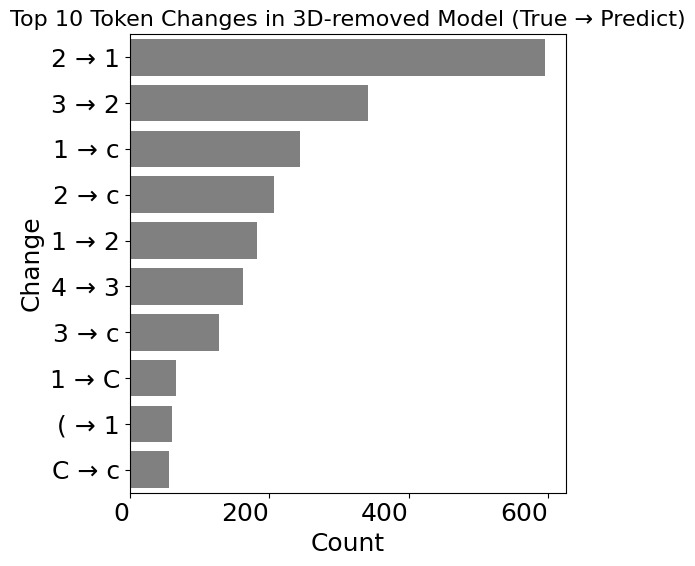

In [29]:
#Fig S7-d
from collections import Counter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/workspace/2403_SMARTS/tox_reset.csv")
df2 = pd.read_csv("/workspace/2403_SMARTS/tox_normal.csv")
df3 = pd.read_csv("/workspace/2403_SMARTS/tox_processed.csv")
df4 = pd.read_csv("/workspace/2403_SMARTS/tox_reset_normal.csv")
c=pd.read_csv("/workspace/2406_paper/large_vocs_true.csv")
mapping = {'<padding>': 0, '<start>': 1, '<end>': 2, '[Si': 3, '[Sc': 4, '[Ni': 5, '[In': 6, '[Sn': 7, '@@': 8, 'He': 9, 'Li': 10, 'Be': 11, 'Ne': 12, 'Na': 13, 'Mg': 14, 'Al': 15, 'Cl': 16, 'Ar': 17, 'Ca': 18, 'Ti': 19, 'Cr': 20, 'Mn': 21, 'Fe': 22, 'Co': 23, 'Cu': 24, 'Zn': 25, 'Ga': 26, 'Ge': 27, 'As': 28, 'Se': 29, 'Br': 30, 'Kr': 31, 'Rb': 32, 'Sr': 33, 'Zr': 34, 'Nb': 35, 'Mo': 36, 'Tc': 37, 'Ru': 38, 'Rh': 39, 'Pd': 40, 'Ag': 41, 'Cd': 42, 'Sb': 43, 'Te': 44, 'Xe': 45, 'Cs': 46, 'Ba': 47, 'La': 48, 'Ce': 49, 'Pr': 50, 'Nd': 51, 'Pm': 52, 'Sm': 53, 'Eu': 54, 'Gd': 55, 'Tb': 56, 'Dy': 57, 'Ho': 58, 'Er': 59, 'Tm': 60, 'Yb': 61, 'Lu': 62, 'Hf': 63, 'Ta': 64, 'Re': 65, 'Os': 66, 'Ir': 67, 'Pt': 68, 'Au': 69, 'Hg': 70, 'Tl': 71, 'Pb': 72, 'Bi': 73, 'Po': 74, 'At': 75, 'Rn': 76, 'Fr': 77, 'Ra': 78, 'Ac': 79, 'Th': 80, 'Pa': 81, 'se': 82, 'te': 83, '0': 84, '1': 85, '2': 86, '3': 87, '4': 88, '5': 89, '6': 90, '7': 91, '8': 92, '9': 93, '(': 94, ')': 95, '[': 96, ']': 97, ':': 98, '=': 99, '@': 100, '+': 101, '/': 102, '\\': 103, '.': 104, '-': 105, '#': 106, '%': 107, 'c': 108, 'i': 109, 'o': 110, 'n': 111, 'p': 112, 's': 113, 'b': 114, 'H': 115, 'B': 116, 'C': 117, 'N': 118, 'O': 119, 'F': 120, 'P': 121, 'S': 122, 'K': 123, 'V': 124, 'Y': 125, 'I': 126, 'W': 127, 'U': 128}
Token = VocabularyTokenizer(vocs=c["voc"])

all_elements = set()

for fi in [df,df2,df3,df4]:
    for i in range(len(fi)):
        all_elements.update(Token.tokenize(fi.loc[i, 'predict']))
        all_elements.update(Token.tokenize(fi.loc[i, 'true']))

filtered_mapping = {key: value for key, value in mapping.items() if value in all_elements}
filtered_values = [value for value in filtered_mapping.values() ]
 
total_diff_count = Counter()

reverse_mapping = {v: k for k, v in filtered_mapping.items()}

for i in range(len(df)):
    base_value = df.loc[i, 'predict']
    compare_value = df.loc[i, 'true']
    
    k = Token.tokenize(base_value)
    l = Token.tokenize(compare_value)
    differences = []


    for a, b in zip(k, l):
        if a - b != 0:
            differences.append((reverse_mapping[a], reverse_mapping[b]))
            
    total_diff_count.update(differences)
    

top_diffs = total_diff_count.most_common(10)

before_tokens = [pair[0][0] for pair in top_diffs]
after_tokens = [pair[0][1] for pair in top_diffs]
counts = [pair[1] for pair in top_diffs]

df_plot = pd.DataFrame({
    'Change': [f'{a} → {b}' for b, a in zip(before_tokens, after_tokens)],
    'Before': before_tokens,
    'After': after_tokens,
    'Count': counts
})
plt.rcParams["font.size"] = 18

plt.figure(figsize=(6, 6))
ax = sns.barplot(y='Change', x='Count', data=df_plot, color="gray")

plt.title('Top 10 Token Changes in 3D-removed Model (True → Predict)',fontsize=16)
plt.xticks(ha='right')
plt.tight_layout()
plt.show()